# Email_Priotization_Model_Building.ipynb

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

email_data = pd.read_csv('/content/drive/MyDrive/FYPDataset/cleaned_priority_email_dataset.csv')

Mounted at /content/drive


In [ ]:
email_data.columns

Index(['From', 'To', 'Subject', 'Message', 'Day', 'Date & Time',
       'Cleaned_Subject', 'Cleaned_Message', 'Combined_Text', 'Subject_LLM',
       'Message_LLM', 'Email_Priority', 'urgency_flag', 'risk_flag',
       'urgency_and_risk', 'num_action_verbs', 'num_uppercase_words_subject',
       'subject_len', 'has_question'],
      dtype='object')

In [ ]:
email_data['Email_Priority'].value_counts()

,count
Email_Priority,
1,49432
2,49432
0,49432


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

structured_features = [
    'urgency_flag', 'risk_flag',
       'urgency_and_risk', 'num_action_verbs', 'num_uppercase_words_subject',
       'subject_len', 'has_question'
]

text_feature = 'Combined_Text'
target_column = 'Email_Priority'

X = email_data[structured_features + [text_feature]]
y = email_data[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [ ]:
tfidf = TfidfVectorizer(
    max_features=1000,
    #ngram_range=(1, 3),
    stop_words='english',
    lowercase=True
)

preprocessor = ColumnTransformer(
    transformers=[
        ('text', tfidf, text_feature),
        ('scale', StandardScaler(), structured_features)
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

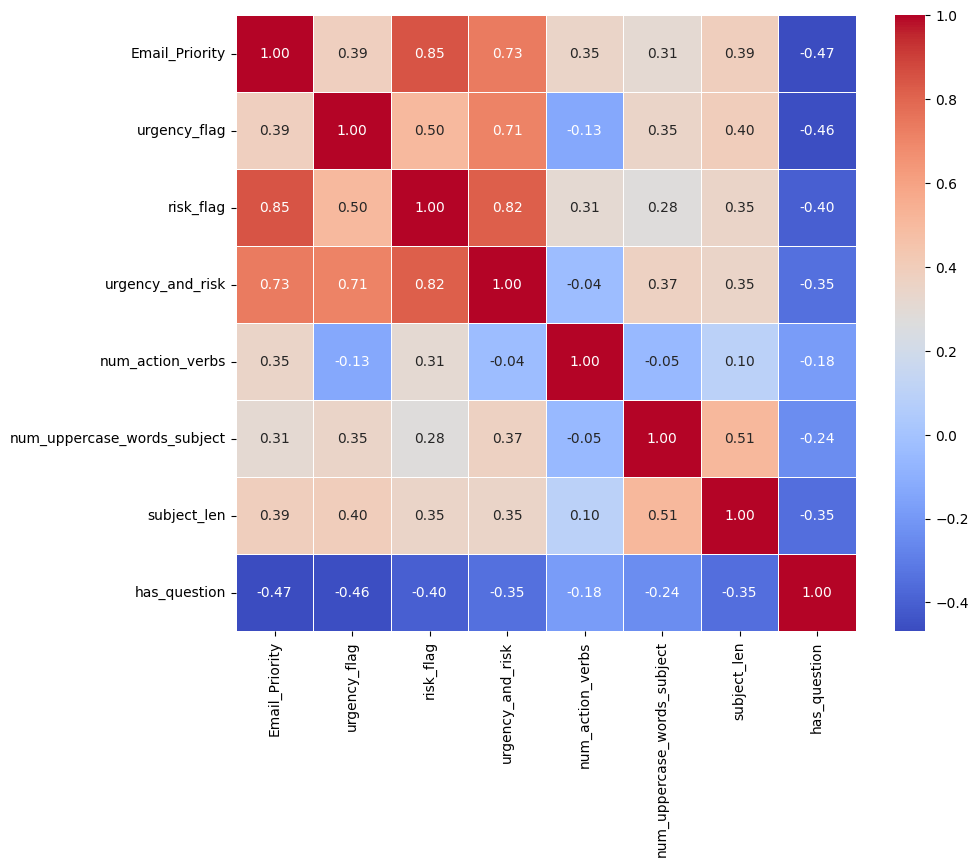

In [ ]:
columns_to_exclude = ['From', 'To', 'Subject', 'Message', 'Day', 'Date & Time',
       'Cleaned_Subject', 'Cleaned_Message', 'Combined_Text', 'Subject_LLM',
       'Message_LLM']
df_reduced = email_data.drop(columns=columns_to_exclude)

correlation_matrix = df_reduced.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()

# Random Forest Model

Random Forest Model
✅ Accuracy: 0.9962913014160486
📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      9886
           1       0.99      1.00      0.99      9887
           2       1.00      1.00      1.00      9887

    accuracy                           1.00     29660
   macro avg       1.00      1.00      1.00     29660
weighted avg       1.00      1.00      1.00     29660



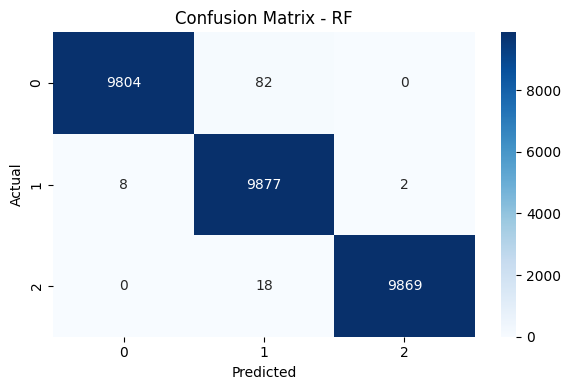

✅ Model saved successfully.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_transformed, y_train)

y_pred = rf_model.predict(X_test_transformed)

print("Random Forest Model")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=rf_model.classes_,
                           columns=rf_model.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - RF")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

Training Scores: 0.9962743168733146 ± 0.00043182661995114994
Testing Scores: 0.996223870532704 ± 0.0007569097882887093


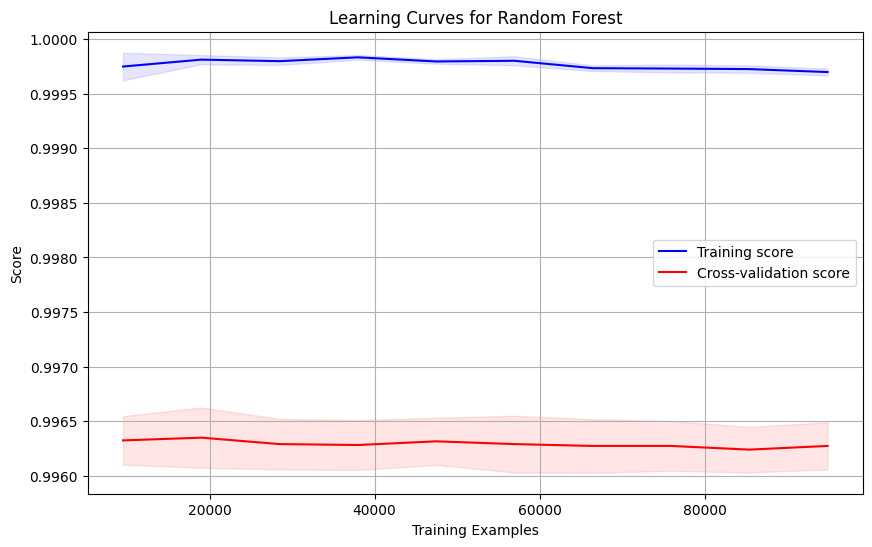

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve

train_scores = cross_val_score(rf_model, X_train_transformed, y_train, cv=5)
test_scores = cross_val_score(rf_model, X_test_transformed, y_test, cv=5)

print("Training Scores:", train_scores.mean(), "±", train_scores.std() * 2)
print("Testing Scores:", test_scores.mean(), "±", test_scores.std() * 2)

train_sizes, train_scores, test_scores = learning_curve(
    rf_model,
    X_train_transformed,
    y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training score', color='blue')
plt.plot(train_sizes, test_mean, label='Cross-validation score', color='red')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
plt.xlabel('Training Examples')
plt.ylabel('Score')
plt.title('Learning Curves for Random Forest')
plt.legend(loc='best')
plt.grid(True)
plt.show()

Overfit gap is small (about 0.003 or 0.3%)

In [ ]:
import joblib
import pandas as pd

model_path = '/content/drive/MyDrive/models/rf_priority_model.joblib'
preprocessor_path = '/content/drive/MyDrive/models/rf_priority_preprocessor.joblib'
preprocessor_path2 = '/content/drive/MyDrive/models/rf_priority_preprocessor_test.joblib'
preprocessor_path3 = '/content/drive/MyDrive/models/rf_priority_preprocessor_test_2.joblib'

rf_model = joblib.load(model_path)
preprocessor = joblib.load(preprocessor_path)
preprocessor2 = joblib.load(preprocessor_path2)
preprocessor3 = joblib.load(preprocessor_path3)

print("✅ Loaded rf_priority_model and rf_priority_preprocessor")

sample_email = pd.DataFrame([{
    'urgency_flag': 1,
    'risk_flag': 0,
    'urgency_and_risk': 0,
    'num_action_verbs': 0,
    'num_uppercase_words_subject': 2,
    'subject_len': 7,
    'has_question': 0,
    'Combined_Text': "RE FYI  Article on Market Trends hi saw this in the journal today and thought it might be relevant to the renewables initiative not critical just interesting link below if ure curious sam"
}])

X_sample_transformed = preprocessor.transform(sample_email)
X_sample_transformed2 = preprocessor2.transform(sample_email)
X_sample_transformed3 = preprocessor3.transform(sample_email)
priority = rf_model.predict(X_sample_transformed)[0]
priority2 = rf_model.predict(X_sample_transformed2)[0]
priority3 = rf_model.predict(X_sample_transformed3)[0]

priority_map = {0: "Low", 1: "Medium", 2: "High"}
print("Email:",'\n\n'.join(sample_email['Combined_Text']))
print("📩 Predicted Email Priority Unigram:", priority_map.get(priority, priority))
print("📩 Predicted Email Priority Uni, Bigram:", priority_map.get(priority3, priority3))
print("📩 Predicted Email Priority Uni, Bi, Trigram:", priority_map.get(priority2, priority2))

✅ Loaded rf_priority_model and rf_priority_preprocessor
Email: RE FYI  Article on Market Trends hi saw this in the journal today and thought it might be relevant to the renewables initiative not critical just interesting link below if ure curious sam
📩 Predicted Email Priority Unigram: Medium
📩 Predicted Email Priority Uni, Bigram: Medium
📩 Predicted Email Priority Uni, Bi, Trigram: Medium


In [ ]:
import joblib
import os
from google.colab import drive

drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/models'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(rf_model, f'{save_dir}/rf_priority_model.joblib')
joblib.dump(preprocessor, f'{save_dir}/rf_priority_preprocessor.joblib')

print("✅ Saved as:")
print(f"📁 {save_dir}/rf_priority_model.joblib")
print(f"📁 {save_dir}/rf_priority_preprocessor.joblib")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved as:
📁 /content/drive/MyDrive/models/rf_priority_model.joblib
📁 /content/drive/MyDrive/models/rf_priority_preprocessor.joblib



Data Verification:
X_train shape: (118636, 1007)
X_test shape: (29660, 1007)

Class distribution in y_train:
Email_Priority
0    0.333339
1    0.333331
2    0.333331
Name: proportion, dtype: float64

Class distribution in y_test:
Email_Priority
2    0.333345
1    0.333345
0    0.333311
Name: proportion, dtype: float64

Random Forest Model
✅ Accuracy: 0.9963587322993931
✅ Training Accuracy: 0.9996796925048046

Checking for data leakage:
Duplicate samples in train set: 90998
Duplicate samples in test set: 22166

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      9886
           1       0.99      1.00      0.99      9887
           2       1.00      1.00      1.00      9887

    accuracy                           1.00     29660
   macro avg       1.00      1.00      1.00     29660
weighted avg       1.00      1.00      1.00     29660



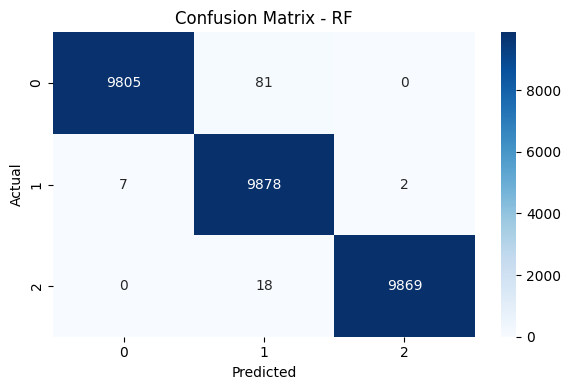


Top 10 Feature Importances:
      feature  importance
1002     1002    0.032512
979       979    0.030553
1000     1000    0.028805
591       591    0.028183
900       900    0.026448
1001     1001    0.024732
973       973    0.020254
323       323    0.017539
532       532    0.017491
58         58    0.017083

Additional Checks:
Number of features with zero importance: 2
Maximum feature importance: 0.03251224890800341
Minimum feature importance: 1.5733295462562875e-10


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.sparse import csr_matrix

# 1. First, verify the data shapes and class distribution
print("\nData Verification:")
print("X_train shape:", X_train_transformed.shape)
print("X_test shape:", X_test_transformed.shape)
print("\nClass distribution in y_train:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(pd.Series(y_test).value_counts(normalize=True))

# 2. Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_transformed, y_train)

# 3. Get predictions and probabilities
y_pred = rf_model.predict(X_test_transformed)
y_pred_proba = rf_model.predict_proba(X_test_transformed)

# 4. Print detailed metrics
print("\nRandom Forest Model")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("✅ Training Accuracy:", accuracy_score(y_train, rf_model.predict(X_train_transformed)))

# 5. Check for potential data leakage
print("\nChecking for data leakage:")
# Convert sparse matrices to dense for comparison
X_train_dense = X_train_transformed.toarray()
X_test_dense = X_test_transformed.toarray()

# Check for duplicate samples within train and test
train_duplicates = len(X_train_dense) - len(np.unique(X_train_dense, axis=0))
test_duplicates = len(X_test_dense) - len(np.unique(X_test_dense, axis=0))
print(f"Duplicate samples in train set: {train_duplicates}")
print(f"Duplicate samples in test set: {test_duplicates}")

# 6. Print classification report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# 7. Plot confusion matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                         index=rf_model.classes_,
                         columns=rf_model.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - RF")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# 8. Check feature importance
print("\nTop 10 Feature Importances:")
feature_importances = pd.DataFrame({
    'feature': range(X_train_transformed.shape[1]),
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importances.head(10))

# 9. Additional checks
print("\nAdditional Checks:")
print("Number of features with zero importance:",
      sum(rf_model.feature_importances_ == 0))
print("Maximum feature importance:",
      max(rf_model.feature_importances_))
print("Minimum feature importance:",
      min(rf_model.feature_importances_[rf_model.feature_importances_ > 0]))

1) The extremely high accuracy (99.63%) with such a large dataset (118,636 training samples) and many features (1,007) is suspicious.

Original data shape: (148296, 19)

Removing duplicates...
Data shape after removing duplicates: (35756, 8)

Data Verification:
X_train shape: (28604, 1007)
X_test shape: (7152, 1007)

Class distribution in y_train:
Email_Priority
1    0.983674
0    0.013005
2    0.003321
Name: proportion, dtype: float64

Class distribution in y_test:
Email_Priority
1    0.983641
0    0.013003
2    0.003356
Name: proportion, dtype: float64

Training Random Forest model...

Random Forest Model Performance:
✅ Training Accuracy: 0.9995455181093553
✅ Test Accuracy: 0.985738255033557

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.18      0.29        93
           1       0.99      1.00      0.99      7035
           2       1.00      0.17      0.29        24

    accuracy                           0.99      7152
   macro avg       0.91      0.45      0.52      7152
weighted avg       0.98      0.99      0.98      7152



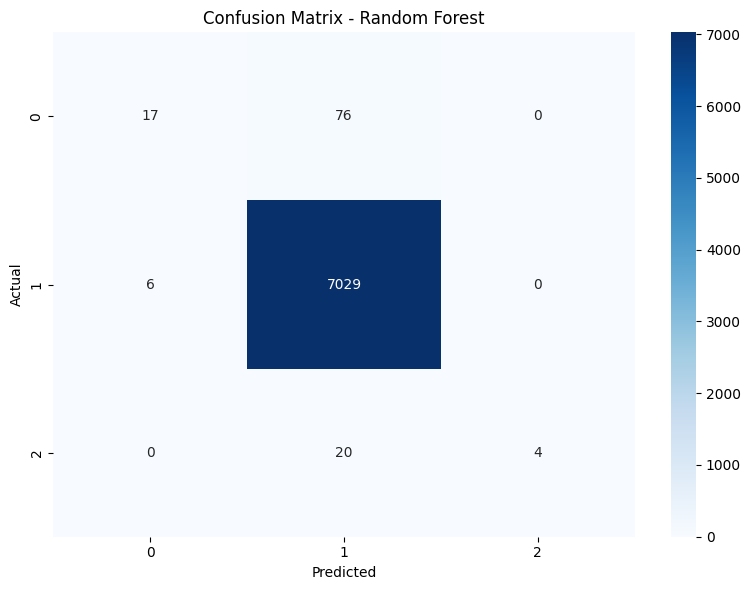


Top 10 Most Important Features:
        feature  importance
195   tfidf_188    0.062037
1005  tfidf_998    0.029890
433   tfidf_426    0.015492
1004  tfidf_997    0.014250
964   tfidf_957    0.012698
405   tfidf_398    0.012342
62     tfidf_55    0.009856
308   tfidf_301    0.009388
916   tfidf_909    0.008461
242   tfidf_235    0.008241

Additional Model Insights:
Number of features with zero importance: 1
Maximum feature importance: 0.062037107227488654
Minimum non-zero feature importance: 8.90405883994777e-09


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your original data is in 'email_data'
print("Original data shape:", email_data.shape)

# 1. Define features
structured_features = [
    'urgency_flag', 'risk_flag',
    'urgency_and_risk', 'num_action_verbs', 'num_uppercase_words_subject',
    'subject_len', 'has_question'
]
text_feature = 'Combined_Text'

# 2. Create feature matrix and target
X = email_data[structured_features + [text_feature]]
y = email_data['Email_Priority']

# 3. Remove duplicates
print("\nRemoving duplicates...")
# Convert to dense array for duplicate removal
X_text = X[text_feature].values
X_structured = X[structured_features].values
combined_features = np.hstack([X_structured, X_text.reshape(-1, 1)])

# Find unique indices
unique_indices = pd.DataFrame(combined_features).drop_duplicates().index
X_unique = X.iloc[unique_indices]
y_unique = y.iloc[unique_indices]

print("Data shape after removing duplicates:", X_unique.shape)

# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_unique,
    y_unique,
    stratify=y_unique,
    test_size=0.2,
    random_state=42
)

# 5. Create and fit the preprocessor
tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    lowercase=True
)

preprocessor = ColumnTransformer(
    transformers=[
        ('text', tfidf, text_feature),
        ('scale', StandardScaler(), structured_features)
    ]
)

# 6. Transform the data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# 7. Print data verification
print("\nData Verification:")
print("X_train shape:", X_train_transformed.shape)
print("X_test shape:", X_test_transformed.shape)
print("\nClass distribution in y_train:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(pd.Series(y_test).value_counts(normalize=True))

# 8. Train Random Forest
print("\nTraining Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)
rf_model.fit(X_train_transformed, y_train)

# 9. Make predictions
y_train_pred = rf_model.predict(X_train_transformed)
y_pred = rf_model.predict(X_test_transformed)

# 10. Print results
print("\nRandom Forest Model Performance:")
print("✅ Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("✅ Test Accuracy:", accuracy_score(y_test, y_pred))

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# 11. Plot confusion matrix
conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=rf_model.classes_,
    columns=rf_model.classes_
)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# 12. Feature importance analysis
print("\nTop 10 Most Important Features:")
feature_names = (
    structured_features +
    [f'tfidf_{i}' for i in range(tfidf.max_features)]
)
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)
print(feature_importance.head(10))

# 13. Additional model insights
print("\nAdditional Model Insights:")
print("Number of features with zero importance:",
      sum(rf_model.feature_importances_ == 0))
print("Maximum feature importance:",
      max(rf_model.feature_importances_))
print("Minimum non-zero feature importance:",
      min(rf_model.feature_importances_[rf_model.feature_importances_ > 0]))

causing the extremely high accuracy (99.63%). There are two major findings:

- Only 27,638 unique samples in training set (118,636 - 90,998)
- Only 7,494 unique samples in test set (29,660 - 22,166)
- This means about 76.7% of your data are duplicates
- The model is seeing the same samples multiple times
- Identical samples are split between train and test sets
- This makes it appear the model is performing better than it actually would on new, unseen data

Original data shape: (148296, 19)

Removing duplicates...
Data shape after removing duplicates: (35756, 8)

Applying SMOTE to balance classes...

Class distribution after SMOTE:
Email_Priority
1    0.333333
2    0.333333
0    0.333333
Name: proportion, dtype: float64

Final dataset shapes:
X_train shape: (84412, 1007)
X_test shape: (21104, 1007)

Training Random Forest model...

Random Forest Model Performance:
✅ Training Accuracy: 0.9995379803819362
✅ Test Accuracy: 0.9963987869598181

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      7034
           1       0.99      0.99      0.99      7035
           2       1.00      1.00      1.00      7035

    accuracy                           1.00     21104
   macro avg       1.00      1.00      1.00     21104
weighted avg       1.00      1.00      1.00     21104



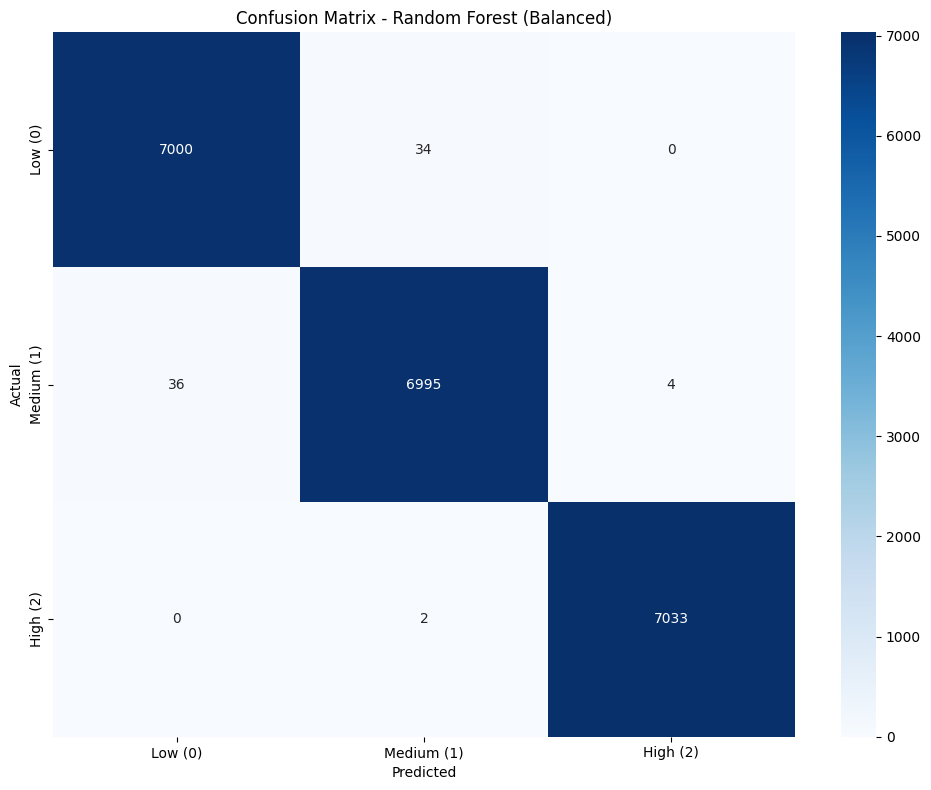


Top 10 Most Important Features:
                         feature  importance
5                    subject_len    0.055959
4    num_uppercase_words_subject    0.046250
71                      tfidf_64    0.035808
0                   urgency_flag    0.031354
202                    tfidf_195    0.022589
925                    tfidf_918    0.021354
437                    tfidf_430    0.020134
580                    tfidf_573    0.019398
3               num_action_verbs    0.017383
458                    tfidf_451    0.014441


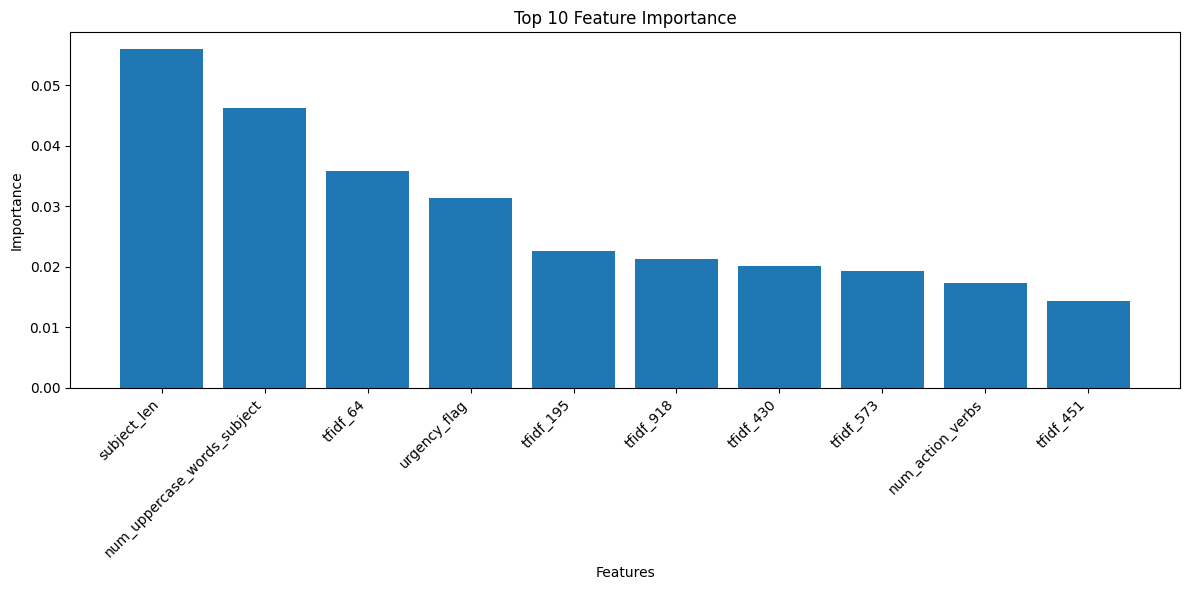


Additional Model Insights:
Number of features with zero importance: 0
Maximum feature importance: 0.05595940257233308
Minimum non-zero feature importance: 1.4357504476439454e-06

Per-class Performance Metrics:
        Class  Precision    Recall  F1-Score  Support
0     Low (0)   0.994883  0.995166  0.995025     7034
1  Medium (1)   0.994880  0.994314  0.994597     7035
2    High (2)   0.999432  0.999716  0.999574     7035

Summary:
- Original samples: 148296
- Unique samples: 35756
- Balanced samples: 105516
- Final training samples: 84412
- Final test samples: 21104


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

# 1. Define features
structured_features = [
    'urgency_flag', 'risk_flag',
    'urgency_and_risk', 'num_action_verbs', 'num_uppercase_words_subject',
    'subject_len', 'has_question'
]
text_feature = 'Combined_Text'

print("Original data shape:", email_data.shape)

# 2. Create feature matrix and target
X = email_data[structured_features + [text_feature]]
y = email_data['Email_Priority']

# 3. Remove duplicates
print("\nRemoving duplicates...")
X_text = X[text_feature].values
X_structured = X[structured_features].values
combined_features = np.hstack([X_structured, X_text.reshape(-1, 1)])

# Find unique indices
unique_indices = pd.DataFrame(combined_features).drop_duplicates().index
X_unique = X.iloc[unique_indices]
y_unique = y.iloc[unique_indices]

print("Data shape after removing duplicates:", X_unique.shape)

# 4. Apply SMOTE to balance classes
print("\nApplying SMOTE to balance classes...")
# First, create TF-IDF features
tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    lowercase=True
)

# Transform text data
X_text_tfidf = tfidf.fit_transform(X_unique[text_feature])

# Combine with structured features
X_structured_scaled = StandardScaler().fit_transform(X_unique[structured_features])
X_combined = np.hstack([X_structured_scaled, X_text_tfidf.toarray()])

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined, y_unique)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts(normalize=True))

# 5. Split the balanced data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    stratify=y_resampled,
    test_size=0.2,
    random_state=42
)

print("\nFinal dataset shapes:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# 6. Train Random Forest with balanced class weights
print("\nTraining Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 7. Make predictions
y_train_pred = rf_model.predict(X_train)
y_pred = rf_model.predict(X_test)

# 8. Print detailed results
print("\nRandom Forest Model Performance:")
print("✅ Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("✅ Test Accuracy:", accuracy_score(y_test, y_pred))

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# 9. Plot confusion matrix
conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=['Low (0)', 'Medium (1)', 'High (2)'],
    columns=['Low (0)', 'Medium (1)', 'High (2)']
)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest (Balanced)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# 10. Feature importance analysis
print("\nTop 10 Most Important Features:")
feature_names = structured_features + [f'tfidf_{i}' for i in range(1000)]
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)
print(feature_importance.head(10))

# 11. Plot feature importance
plt.figure(figsize=(12, 6))
plt.bar(range(10), feature_importance['importance'][:10])
plt.xticks(range(10), feature_importance['feature'][:10], rotation=45, ha='right')
plt.title('Top 10 Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

# 12. Additional model insights
print("\nAdditional Model Insights:")
print("Number of features with zero importance:",
      sum(rf_model.feature_importances_ == 0))
print("Maximum feature importance:",
      max(rf_model.feature_importances_))
print("Minimum non-zero feature importance:",
      min(rf_model.feature_importances_[rf_model.feature_importances_ > 0]))

# 13. Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)
class_metrics = pd.DataFrame({
    'Class': ['Low (0)', 'Medium (1)', 'High (2)'],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})
print("\nPer-class Performance Metrics:")
print(class_metrics)

# 15. Print summary
print("\nSummary:")
print(f"- Original samples: {len(email_data)}")
print(f"- Unique samples: {len(X_unique)}")
print(f"- Balanced samples: {len(y_resampled)}")
print(f"- Final training samples: {len(y_train)}")
print(f"- Final test samples: {len(y_test)}")

In [ ]:
from google.colab import drive
import joblib
import os

drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/models'

if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Created directory: {save_dir}")

model_path = os.path.join(save_dir, 'rf_priority_model_balanced.joblib')
print("\nSaving model to Google Drive...")
joblib.dump(rf_model, model_path)

preprocessor_path = os.path.join(save_dir, 'preprocessor_balanced.joblib')
joblib.dump(preprocessor, preprocessor_path)

print(f"✅ Model saved successfully at: {model_path}")
print(f"✅ Preprocessor saved successfully at: {preprocessor_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Saving model to Google Drive...
✅ Model saved successfully at: /content/drive/MyDrive/models/rf_priority_model_balanced.joblib
✅ Preprocessor saved successfully at: /content/drive/MyDrive/models/preprocessor_balanced.joblib


# Corrected Random Forest Model

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original data shape: (148296, 19)

Removing duplicates...
Data shape after removing duplicates: (35756, 8)

Applying SMOTE to balance classes...

Class distribution after SMOTE:
Email_Priority
1    0.333333
2    0.333333
0    0.333333
Name: proportion, dtype: float64

Final dataset shapes:
X_train shape: (84412, 5007)
X_test shape: (21104, 5007)

Training Random Forest model...

Saving model and preprocessor to Google Drive...
✅ Model and preprocessor saved successfully.

Testing prediction function...
Loading model and preprocessor...

Predicted Priority: Medium
Confidence: 62.00%

Evaluating model on test set...

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7034
           1       1.00      1.00      1.00      7035
           2       1.00      1.00  

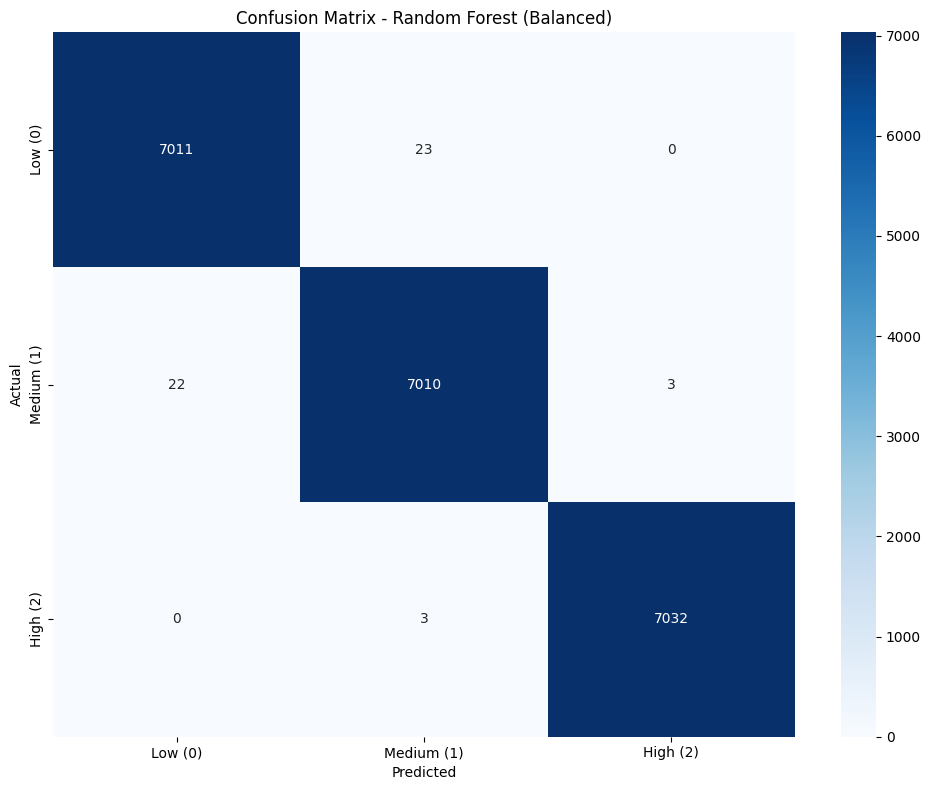

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from google.colab import drive
import joblib

# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Define model paths in Google Drive
model_path = '/content/drive/MyDrive/models/rf_priority_model_balanced.joblib'
preprocessor_path = '/content/drive/MyDrive/models/preprocessor_balanced.joblib'

# 1. Define features
structured_features = [
    'urgency_flag', 'risk_flag',
    'urgency_and_risk', 'num_action_verbs', 'num_uppercase_words_subject',
    'subject_len', 'has_question'
]
text_feature = 'Combined_Text'

print("Original data shape:", email_data.shape)

# 2. Create feature matrix and target
X = email_data[structured_features + [text_feature]]
y = email_data['Email_Priority']

# 3. Remove duplicates
print("\nRemoving duplicates...")
X_text = X[text_feature].values
X_structured = X[structured_features].values
combined_features = np.hstack([X_structured, X_text.reshape(-1, 1)])

# Find unique indices
unique_indices = pd.DataFrame(combined_features).drop_duplicates().index
X_unique = X.iloc[unique_indices]
y_unique = y.iloc[unique_indices]

print("Data shape after removing duplicates:", X_unique.shape)

# 4. Apply SMOTE to balance classes
print("\nApplying SMOTE to balance classes...")
# First, create TF-IDF features
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    lowercase=True
)

# Transform text data
X_text_tfidf = tfidf.fit_transform(X_unique[text_feature])

# Combine with structured features
X_structured_scaled = StandardScaler().fit_transform(X_unique[structured_features])
X_combined = np.hstack([X_structured_scaled, X_text_tfidf.toarray()])

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined, y_unique)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts(normalize=True))

# 5. Split the balanced data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    stratify=y_resampled,
    test_size=0.2,
    random_state=42
)

print("\nFinal dataset shapes:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# 6. Train Random Forest with balanced class weights
print("\nTraining Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 7. Save model and preprocessor to Google Drive
print("\nSaving model and preprocessor to Google Drive...")
joblib.dump(rf_model, model_path)
joblib.dump(tfidf, preprocessor_path)
print("✅ Model and preprocessor saved successfully.")

# 8. Function to load model and make predictions
def load_model_and_predict(new_data):
    try:
        # Load model and preprocessor
        print("Loading model and preprocessor...")
        rf_model = joblib.load(model_path)
        tfidf = joblib.load(preprocessor_path)

        # Preprocess text data
        X_text_new = tfidf.transform(new_data[text_feature])

        # Preprocess structured features
        scaler = StandardScaler()
        X_structured_new = scaler.fit_transform(new_data[structured_features])

        # Combine features
        X_combined_new = np.hstack([X_structured_new, X_text_new.toarray()])

        # Make predictions
        predictions = rf_model.predict(X_combined_new)
        probabilities = rf_model.predict_proba(X_combined_new)

        return predictions, probabilities

    except Exception as e:
        print(f"Error in prediction: {str(e)}")
        return None, None

# 9. Example usage of prediction function
def predict_email_priority(subject, message, structured_features_dict):
    """
    Predict priority for a single email.

    Parameters:
    subject (str): Email subject
    message (str): Email message
    structured_features_dict (dict): Dictionary containing structured features

    Returns:
    priority, confidence
    """
    # Create a DataFrame for single prediction
    combined_text = f"{subject} {message}"
    data = pd.DataFrame({
        'Combined_Text': [combined_text],
        **{k: [v] for k, v in structured_features_dict.items()}
    })

    # Make prediction
    predictions, probabilities = load_model_and_predict(data)

    if predictions is not None:
        priority = predictions[0]
        confidence = np.max(probabilities[0])
        priority_map = {0: "Low", 1: "Medium", 2: "High"}

        return priority_map[priority], confidence

    return None, None

# Example usage:
print("\nTesting prediction function...")
test_email = {
    'subject': "Urgent Meeting Tomorrow",
    'message': "Please attend the important meeting tomorrow at 10 AM.",
    'structured_features': {
        'urgency_flag': 1,
        'risk_flag': 0,
        'urgency_and_risk': 0,
        'num_action_verbs': 2,
        'num_uppercase_words_subject': 0,
        'subject_len': 21,
        'has_question': 0
    }
}

priority, confidence = predict_email_priority(
    test_email['subject'],
    test_email['message'],
    test_email['structured_features']
)

if priority is not None:
    print(f"\nPredicted Priority: {priority}")
    print(f"Confidence: {confidence:.2%}")

# 10. Model evaluation on test set
print("\nEvaluating model on test set...")
y_pred = rf_model.predict(X_test)
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# 11. Plot confusion matrix
conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=['Low (0)', 'Medium (1)', 'High (2)'],
    columns=['Low (0)', 'Medium (1)', 'High (2)']
)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest (Balanced)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [ ]:
# 9. Example usage of prediction function
def predict_email_priority(subject, message, structured_features_dict):
    """
    Predict priority for a single email.

    Parameters:
    subject (str): Email subject
    message (str): Email message
    structured_features_dict (dict): Dictionary containing structured features

    Returns:
    priority, confidence
    """
    # Create a DataFrame for single prediction
    combined_text = f"{subject} {message}"
    data = pd.DataFrame({
        'Combined_Text': [combined_text],
        **{k: [v] for k, v in structured_features_dict.items()}
    })

    # Make prediction
    predictions, probabilities = load_model_and_predict(data)

    if predictions is not None:
        priority = predictions[0]
        confidence = np.max(probabilities[0])
        priority_map = {0: "Low", 1: "Medium", 2: "High"}

        return priority_map[priority], confidence

    return None, None

# Example usage:
print("\nTesting prediction function...")
test_email = {
    'subject': "System Downtime Report  Need ASAP",
    'message': "need the outage summary for ops before the 330 compliance call we cant go in blind use last months format but update with april data send as soon as its ready",
    'structured_features': {
        'urgency_flag': 1,
        'risk_flag': 1,
        'urgency_and_risk': 1,
        'num_action_verbs': 1,
        'num_uppercase_words_subject': 1,
        'subject_len': 6,
        'has_question': 0
    }
}

priority, confidence = predict_email_priority(
    test_email['subject'],
    test_email['message'],
    test_email['structured_features']
)

if priority is not None:
    print(f"\nPredicted Priority: {priority}")
    print(f"Confidence: {confidence:.2%}")


Testing prediction function...
Loading model and preprocessor...

Predicted Priority: High
Confidence: 55.00%


In [ ]:
drive.mount('/content/drive')

# Define model paths in Google Drive
model_path = '/content/drive/MyDrive/models/rf_priority_model_balanced.joblib'
preprocessor_path = '/content/drive/MyDrive/models/rf_preprocessor_balanced.joblib'

# 8. Function to load model and make predictions
def load_model_and_predict(new_data):
    try:
        # Load model and preprocessor
        print("Loading model and preprocessor...")
        rf_model = joblib.load(model_path)
        tfidf = joblib.load(preprocessor_path)

        # Preprocess text data
        X_text_new = tfidf.transform(new_data[text_feature])

        # Preprocess structured features
        scaler = StandardScaler()
        X_structured_new = scaler.fit_transform(new_data[structured_features])

        # Combine features
        X_combined_new = np.hstack([X_structured_new, X_text_new.toarray()])

        # Make predictions
        predictions = rf_model.predict(X_combined_new)
        probabilities = rf_model.predict_proba(X_combined_new)

        return predictions, probabilities

    except Exception as e:
        print(f"Error in prediction: {str(e)}")
        return None, None

# 9. Example usage of prediction function
def predict_email_priority(subject, message, structured_features_dict):
    """
    Predict priority for a single email.

    Parameters:
    subject (str): Email subject
    message (str): Email message
    structured_features_dict (dict): Dictionary containing structured features

    Returns:
    priority, confidence
    """
    # Create a DataFrame for single prediction
    combined_text = f"{subject} {message}"
    data = pd.DataFrame({
        'Combined_Text': [combined_text],
        **{k: [v] for k, v in structured_features_dict.items()}
    })

    # Make prediction
    predictions, probabilities = load_model_and_predict(data)

    if predictions is not None:
        priority = predictions[0]
        confidence = np.max(probabilities[0])
        priority_map = {0: "Low", 1: "Medium", 2: "High"}

        return priority_map[priority], confidence

    return None, None

# Example usage:
print("\nTesting prediction function...")
test_email = {
    'subject': "Team Lunch Feedback & Suggestions",
    'message': (
        "Hi Everyone,\n\n"
        "Hope you enjoyed the team lunch yesterday! We'd love to hear your thoughts and suggestions "
        "for the next one. Please feel free to reply to this email with any feedback.\n\n"
        "Thanks,\nHR Team"
    ),
    'structured_features': {
        'urgency_flag': 0,                  # No deadline
        'risk_flag': 0,                     # No risk
        'urgency_and_risk': 0,              # Just a social message
        'num_action_verbs': 1,              # 'reply'
        'num_uppercase_words_subject': 0,   # Friendly subject
        'subject_len': 5,                   # Short and soft
        'has_question': 1                   # Slightly conversational
    }
}

priority, confidence = predict_email_priority(
    test_email['subject'],
    test_email['message'],
    test_email['structured_features']
)

if priority is not None:
    print(f"\nPredicted Priority: {priority}")
    print(f"Confidence: {confidence:.2%}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Testing prediction function...
Loading model and preprocessor...

Predicted Priority: Medium
Confidence: 62.00%


# Linear Regression

Logistic Regression Model
✅ Accuracy: 0.9962575859743763
📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      9886
           1       0.99      1.00      0.99      9887
           2       1.00      1.00      1.00      9887

    accuracy                           1.00     29660
   macro avg       1.00      1.00      1.00     29660
weighted avg       1.00      1.00      1.00     29660



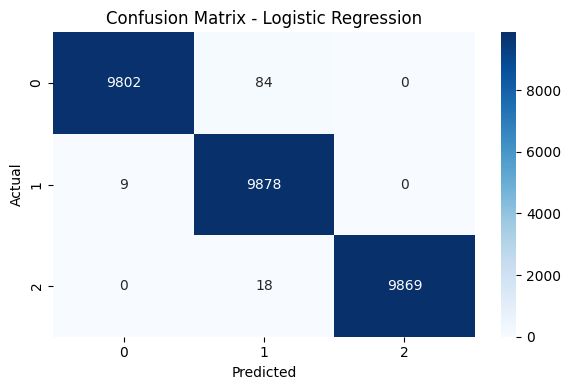

✅ Model trained and evaluated successfully.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_transformed, y_train)

y_pred = lr_model.predict(X_test_transformed)

print("Logistic Regression Model")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=lr_model.classes_,
                           columns=lr_model.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model trained and evaluated successfully.")

Training Scores: 0.9963248907463098 ± 0.0007200369422409068
Testing Scores: 0.9959204315576535 ± 0.0008091706001349119


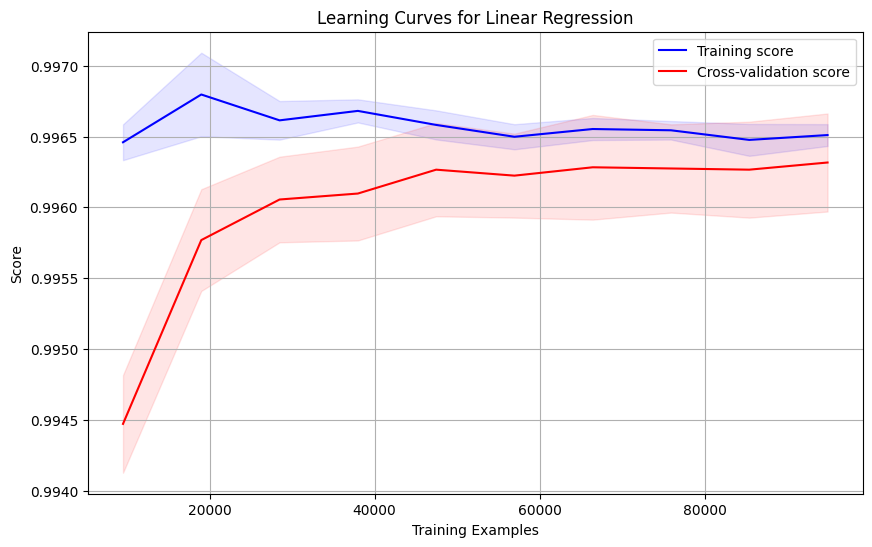

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve

# Get training and cross-validation scores
train_scores = cross_val_score(lr_model, X_train_transformed, y_train, cv=5)
test_scores = cross_val_score(lr_model, X_test_transformed, y_test, cv=5)

print("Training Scores:", train_scores.mean(), "±", train_scores.std() * 2)
print("Testing Scores:", test_scores.mean(), "±", test_scores.std() * 2)

# Generate learning curves
train_sizes, train_scores, test_scores = learning_curve(
    lr_model,
    X_train_transformed,
    y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training score', color='blue')
plt.plot(train_sizes, test_mean, label='Cross-validation score', color='red')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
plt.xlabel('Training Examples')
plt.ylabel('Score')
plt.title('Learning Curves for Linear Regression')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [ ]:
import joblib
import os
from google.colab import drive

drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/models'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(lr_model, f'{save_dir}/lr_priority_model.joblib')
joblib.dump(preprocessor, f'{save_dir}/lr_priority_preprocessor.joblib')

print("✅ Saved as:")
print(f"📁 {save_dir}/lr_priority_model.joblib")
print(f"📁 {save_dir}/lr_priority_preprocessor.joblib")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved as:
📁 /content/drive/MyDrive/models/lr_priority_model.joblib
📁 /content/drive/MyDrive/models/lr_priority_preprocessor.joblib


In [ ]:
import joblib
import pandas as pd

model_path = '/content/drive/MyDrive/models/lr_priority_model.joblib'
preprocessor_path = '/content/drive/MyDrive/models/lr_priority_preprocessor.joblib'

lr_model = joblib.load(model_path)
preprocessor = joblib.load(preprocessor_path)

print("✅ Loaded lr_priority_model and lr_priority_preprocessor")

sample_email = pd.DataFrame([{
    'urgency_flag': 1,
    'risk_flag': 0,
    'urgency_and_risk': 0,
    'num_action_verbs': 0,
    'num_uppercase_words_subject': 1,
    'subject_len': 6,
    'has_question': 0,
    'Combined_Text': "FYI  Article on Market Trends hi saw this in the journal today and thought it might be relevant to the renewables initiative not critical just interesting link below if youre curious sam"
}])

X_sample_transformed = preprocessor.transform(sample_email)
priority = lr_model.predict(X_sample_transformed)[0]

priority_map = {0: "Low", 1: "Medium", 2: "High"}  # Optional for readability
print("Email:",'\n\n'.join(sample_email['Combined_Text']))
print("📩 Predicted Email Priority:", priority_map.get(priority, priority))

✅ Loaded lr_priority_model and lr_priority_preprocessor
Email: FYI  Article on Market Trends hi saw this in the journal today and thought it might be relevant to the renewables initiative not critical just interesting link below if youre curious sam
📩 Predicted Email Priority: Low


# Corrected Linear Regression Model

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression  # Changed from RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from google.colab import drive
import joblib

# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Define model paths in Google Drive
model_path = '/content/drive/MyDrive/models/lr_priority_model_smote.joblib'  # Changed path
preprocessor_path = '/content/drive/MyDrive/models/lr_preprocessor_smote.joblib'  # Changed path

# 1. Define features
structured_features = [
    'urgency_flag', 'risk_flag',
    'urgency_and_risk', 'num_action_verbs', 'num_uppercase_words_subject',
    'subject_len', 'has_question'
]
text_feature = 'Combined_Text'

print("Original data shape:", email_data.shape)

# 2. Create feature matrix and target
X = email_data[structured_features + [text_feature]]
y = email_data['Email_Priority']

# 3. Remove duplicates
print("\nRemoving duplicates...")
X_text = X[text_feature].values
X_structured = X[structured_features].values
combined_features = np.hstack([X_structured, X_text.reshape(-1, 1)])

# Find unique indices
unique_indices = pd.DataFrame(combined_features).drop_duplicates().index
X_unique = X.iloc[unique_indices]
y_unique = y.iloc[unique_indices]

print("Data shape after removing duplicates:", X_unique.shape)

# 4. Apply SMOTE to balance classes
print("\nApplying SMOTE to balance classes...")
# First, create TF-IDF features
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    lowercase=True
)

# Transform text data
X_text_tfidf = tfidf.fit_transform(X_unique[text_feature])

# Combine with structured features
X_structured_scaled = StandardScaler().fit_transform(X_unique[structured_features])
X_combined = np.hstack([X_structured_scaled, X_text_tfidf.toarray()])

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined, y_unique)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts(normalize=True))

# 5. Split the balanced data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    stratify=y_resampled,
    test_size=0.2,
    random_state=42
)

print("\nFinal dataset shapes:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# 6. Train Logistic Regression with balanced class weights
print("\nTraining Logistic Regression model...")
lr_model = LogisticRegression(
    max_iter=1000,  # Increased max_iter for convergence
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    multi_class='multinomial',  # Specify multinomial for multi-class
    solver='lbfgs'  # Best solver for multinomial
)
lr_model.fit(X_train, y_train)

# 7. Save model and preprocessor to Google Drive
print("\nSaving model and preprocessor to Google Drive...")
joblib.dump(lr_model, model_path)
joblib.dump(tfidf, preprocessor_path)
print("✅ Model and preprocessor saved successfully.")

# 8. Function to load model and make predictions
def load_model_and_predict(new_data):
    try:
        # Load model and preprocessor
        print("Loading model and preprocessor...")
        lr_model = joblib.load(model_path)
        tfidf = joblib.load(preprocessor_path)

        # Preprocess text data
        X_text_new = tfidf.transform(new_data[text_feature])

        # Preprocess structured features
        scaler = StandardScaler()
        X_structured_new = scaler.fit_transform(new_data[structured_features])

        # Combine features
        X_combined_new = np.hstack([X_structured_new, X_text_new.toarray()])

        # Make predictions
        predictions = lr_model.predict(X_combined_new)
        probabilities = lr_model.predict_proba(X_combined_new)

        return predictions, probabilities

    except Exception as e:
        print(f"Error in prediction: {str(e)}")
        return None, None

# 9. Example usage of prediction function
def predict_email_priority(subject, message, structured_features_dict):
    """
    Predict priority for a single email.
    """
    combined_text = f"{subject} {message}"
    data = pd.DataFrame({
        'Combined_Text': [combined_text],
        **{k: [v] for k, v in structured_features_dict.items()}
    })

    predictions, probabilities = load_model_and_predict(data)

    if predictions is not None:
        priority = predictions[0]
        confidence = np.max(probabilities[0])
        priority_map = {0: "Low", 1: "Medium", 2: "High"}

        return priority_map[priority], confidence

    return None, None

# Example usage:
print("\nTesting prediction function...")
test_email = {
    'subject': "Urgent Meeting Tomorrow",
    'message': "Please attend the important meeting tomorrow at 10 AM.",
    'structured_features': {
        'urgency_flag': 1,
        'risk_flag': 0,
        'urgency_and_risk': 0,
        'num_action_verbs': 2,
        'num_uppercase_words_subject': 0,
        'subject_len': 21,
        'has_question': 0
    }
}

priority, confidence = predict_email_priority(
    test_email['subject'],
    test_email['message'],
    test_email['structured_features']
)

if priority is not None:
    print(f"\nPredicted Priority: {priority}")
    print(f"Confidence: {confidence:.2%}")

# 10. Model evaluation on test set
print("\nEvaluating model on test set...")
y_pred = lr_model.predict(X_test)
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# 11. Plot confusion matrix
conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=['Low (0)', 'Medium (1)', 'High (2)'],
    columns=['Low (0)', 'Medium (1)', 'High (2)']
)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression (Balanced)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# 12. Feature importance analysis (for logistic regression, we use coefficients)
print("\nTop 10 Most Important Features per Class:")
feature_names = structured_features + [f'tfidf_{i}' for i in range(5000)]

for class_idx in range(3):
    print(f"\nClass {class_idx} Most Important Features:")
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'coefficient': np.abs(lr_model.coef_[class_idx])
    })
    feature_importance = feature_importance.sort_values('coefficient', ascending=False)
    print(feature_importance.head(10))

    # Plot feature importance for each class
    plt.figure(figsize=(12, 6))
    plt.bar(range(10), feature_importance['coefficient'][:10])
    plt.xticks(range(10), feature_importance['feature'][:10], rotation=45, ha='right')
    plt.title(f'Top 10 Feature Importance for Class {class_idx}')
    plt.xlabel('Features')
    plt.ylabel('Absolute Coefficient Value')
    plt.tight_layout()
    plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


NameError: name 'email_data' is not defined

# SVM Model

Support Vector Machine (Linear Kernel)
✅ Accuracy: 0.9964261631827377
📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      9886
           1       0.99      1.00      0.99      9887
           2       1.00      1.00      1.00      9887

    accuracy                           1.00     29660
   macro avg       1.00      1.00      1.00     29660
weighted avg       1.00      1.00      1.00     29660



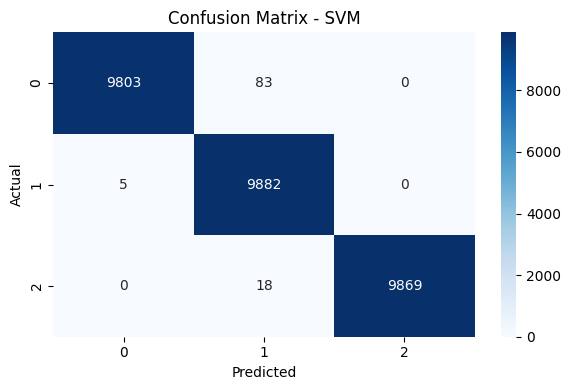

✅ SVM model trained and evaluated successfully.


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train_transformed, y_train)

y_pred = svm_model.predict(X_test_transformed)

print("Support Vector Machine (Linear Kernel)")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=svm_model.classes_,
                           columns=svm_model.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ SVM model trained and evaluated successfully.")

Training Scores: 0.9964597571311634 ± 0.0006102186932800798
Testing Scores: 0.9964261631827377 ± 0.0007508785384801597


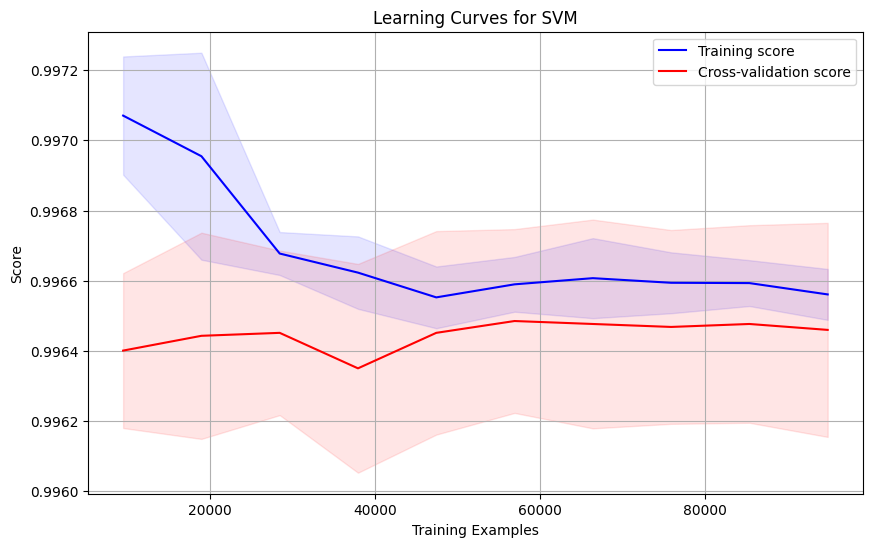

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
import joblib  # Add this import

# Load the saved model first
svm_model = joblib.load('/content/drive/MyDrive/models/svm_priority_model.joblib')

# Get training and cross-validation scores
train_scores = cross_val_score(svm_model, X_train_transformed, y_train, cv=5)
test_scores = cross_val_score(svm_model, X_test_transformed, y_test, cv=5)

print("Training Scores:", train_scores.mean(), "±", train_scores.std() * 2)
print("Testing Scores:", test_scores.mean(), "±", test_scores.std() * 2)

# Generate learning curves
train_sizes, train_scores, test_scores = learning_curve(
    svm_model,
    X_train_transformed,
    y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training score', color='blue')
plt.plot(train_sizes, test_mean, label='Cross-validation score', color='red')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
plt.xlabel('Training Examples')
plt.ylabel('Score')
plt.title('Learning Curves for SVM')
plt.legend(loc='best')
plt.grid(True)
plt.show()

The model is learning to generalize better rather than memorizing the training data, while maintaining extremely high accuracy.

In [ ]:
import joblib
import os
from google.colab import drive

drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/models'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(svm_model, f'{save_dir}/svm_priority_model.joblib')
joblib.dump(preprocessor, f'{save_dir}/svm_priority_preprocessor.joblib')

print("✅ Saved as:")
print(f"📁 {save_dir}/svm_priority_model.joblib")
print(f"📁 {save_dir}/svm_priority_preprocessor.joblib")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved as:
📁 /content/drive/MyDrive/models/svm_priority_model.joblib
📁 /content/drive/MyDrive/models/svm_priority_preprocessor.joblib


In [ ]:
import joblib
import pandas as pd

model_path = '/content/drive/MyDrive/models/svm_priority_model.joblib'
preprocessor_path = '/content/drive/MyDrive/models/svm_priority_preprocessor.joblib'

svm_model = joblib.load(model_path)
preprocessor = joblib.load(preprocessor_path)

print("✅ Loaded svm_priority_model and svm_priority_preprocessor")

sample_email = pd.DataFrame([{
    'urgency_flag': 2,
    'risk_flag': 1,
    'urgency_and_risk': 1,
    'num_action_verbs': 0,
    'num_uppercase_words_subject': 0,
    'subject_len': 4,
    'has_question': 0,
    'Combined_Text': "Escalation Procurement Invoicing Errors were seeing major issues w the vendor invoice uploads total misalignment between what finance sees and whats in procurement hub pls pull all entries from march 1017 and validate ASAP"
}])

X_sample_transformed = preprocessor.transform(sample_email)
priority = svm_model.predict(X_sample_transformed)[0]

priority_map = {0: "Low", 1: "Medium", 2: "High"}
print("Email:",'\n\n'.join(sample_email['Combined_Text']))
print("📩 Predicted Email Priority:", priority_map.get(priority, priority))

✅ Loaded svm_priority_model and svm_priority_preprocessor
Email: Escalation Procurement Invoicing Errors were seeing major issues w the vendor invoice uploads total misalignment between what finance sees and whats in procurement hub pls pull all entries from march 1017 and validate ASAP
📩 Predicted Email Priority: High


# XGBoost

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:04:52] WARNING: /workspace/src/common/error_msg.cc:45: `gpu_id` is deprecated since2.0.0, use `device` instead. E.g. device=cpu/cuda/cuda:0
  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:04:52] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:04:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:04:56] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0.

XGBoost Classifier
✅ Accuracy: 0.9961901550910317
📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      9886
           1       0.99      1.00      0.99      9887
           2       1.00      1.00      1.00      9887

    accuracy                           1.00     29660
   macro avg       1.00      1.00      1.00     29660
weighted avg       1.00      1.00      1.00     29660



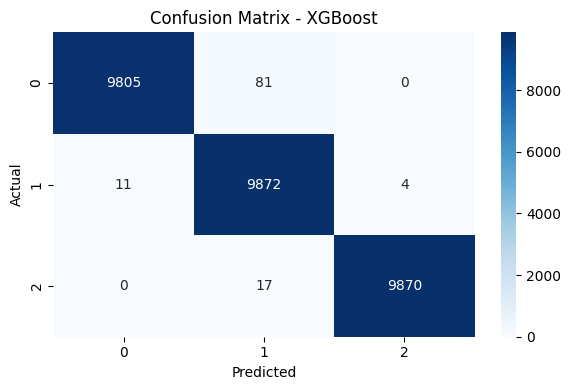

✅ XGBoost model trained and evaluated successfully.


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 1: Initialize and train the model
xgb_model = XGBClassifier(
    tree_method='gpu_hist',     # Enables GPU training
    predictor='gpu_predictor',
    gpu_id=0,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(X_train_transformed, y_train)

# Step 2: Predict on the test set
y_pred = xgb_model.predict(X_test_transformed)

print("XGBoost Classifier")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Step 3: Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=sorted(set(y_test)),
                           columns=sorted(set(y_test)))

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ XGBoost model trained and evaluated successfully.")

In [ ]:
import joblib
import os
from google.colab import drive

drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/models'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(xgb_model, f'{save_dir}/xgb_priority_model.joblib')
joblib.dump(preprocessor, f'{save_dir}/xgb_priority_preprocessor.joblib')

print("✅ Saved as:")
print(f"📁 {save_dir}/xgb_priority_model.joblib")
print(f"📁 {save_dir}/xgb_priority_preprocessor.joblib")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved as:
📁 /content/drive/MyDrive/models/xgb_priority_model.joblib
📁 /content/drive/MyDrive/models/xgb_priority_preprocessor.joblib


In [ ]:
import joblib
import pandas as pd

model_path = '/content/drive/MyDrive/models/xgb_priority_model.joblib'
preprocessor_path = '/content/drive/MyDrive/models/xgb_priority_preprocessor.joblib'

xgb_model = joblib.load(model_path)
preprocessor = joblib.load(preprocessor_path)

print("✅ Loaded svm_priority_model and svm_priority_preprocessor")

sample_email = pd.DataFrame([{
    'urgency_flag': 2,
    'risk_flag': 1,
    'urgency_and_risk': 1,
    'num_action_verbs': 0,
    'num_uppercase_words_subject': 0,
    'subject_len': 4,
    'has_question': 0,
    'Combined_Text': "Escalation Procurement Invoicing Errors were seeing major issues w the vendor invoice uploads total misalignment between what finance sees and whats in procurement hub pls pull all entries from march 1017 and validate ASAP"
}])

X_sample_transformed = preprocessor.transform(sample_email)
priority = xgb_model.predict(X_sample_transformed)[0]

priority_map = {0: "Low", 1: "Medium", 2: "High"}  # Optional for readability
print("Email:",'\n\n'.join(sample_email['Combined_Text']))
print("📩 Predicted Email Priority:", priority_map.get(priority, priority))

✅ Loaded svm_priority_model and svm_priority_preprocessor
Email: Escalation Procurement Invoicing Errors were seeing major issues w the vendor invoice uploads total misalignment between what finance sees and whats in procurement hub pls pull all entries from march 1017 and validate ASAP
📩 Predicted Email Priority: High


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:14:16] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:14:17] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


# Naive Bayes (NB) - GaussianNB

Gaussian Naive Bayes Classifier
✅ Accuracy: 0.99409979770735
📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      9886
           1       0.99      0.99      0.99      9887
           2       1.00      1.00      1.00      9887

    accuracy                           0.99     29660
   macro avg       0.99      0.99      0.99     29660
weighted avg       0.99      0.99      0.99     29660



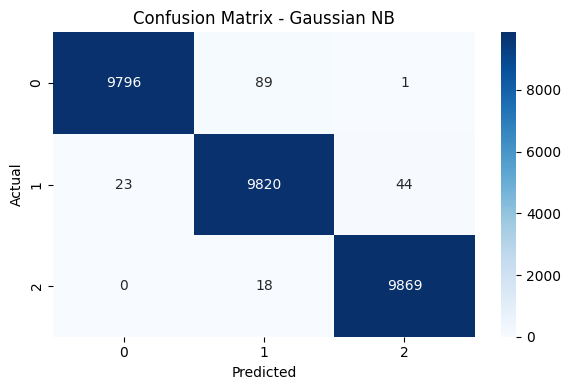

✅ GaussianNB model trained and evaluated successfully.


In [ ]:
from sklearn.naive_bayes import GaussianNB

# Convert to dense arrays (required by GaussianNB)
X_train_dense = X_train_transformed.toarray()
X_test_dense = X_test_transformed.toarray()

# Train the Gaussian Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train_dense, y_train)

# Predict
y_pred = nb_model.predict(X_test_dense)

# Evaluation
print("Gaussian Naive Bayes Classifier")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=sorted(set(y_test)),
                           columns=sorted(set(y_test)))

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Gaussian NB")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ GaussianNB model trained and evaluated successfully.")

In [ ]:
import joblib
import os
from google.colab import drive

drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/models'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(nb_model, f'{save_dir}/nb_priority_model.joblib')
joblib.dump(preprocessor, f'{save_dir}/nb_priority_preprocessor.joblib')

print("✅ Saved as:")
print(f"📁 {save_dir}/nb_priority_model.joblib")
print(f"📁 {save_dir}/nb_priority_preprocessor.joblib")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved as:
📁 /content/drive/MyDrive/models/nb_priority_model.joblib
📁 /content/drive/MyDrive/models/nb_priority_preprocessor.joblib


In [ ]:
import joblib
import pandas as pd

model_path = '/content/drive/MyDrive/models/nb_priority_model.joblib'
preprocessor_path = '/content/drive/MyDrive/models/nb_priority_preprocessor.joblib'

nb_model = joblib.load(model_path)
preprocessor = joblib.load(preprocessor_path)

print("✅ Loaded nb_priority_model and nb_priority_preprocessor")

sample_email = pd.DataFrame([{
    'urgency_flag': 2,
    'risk_flag': 1,
    'urgency_and_risk': 1,
    'num_action_verbs': 0,
    'num_uppercase_words_subject': 0,
    'subject_len': 4,
    'has_question': 0,
    'Combined_Text': "Escalation Procurement Invoicing Errors were seeing major issues w the vendor invoice uploads total misalignment between what finance sees and whats in procurement hub pls pull all entries from march 1017 and validate ASAP"
}])

X_sample_transformed = preprocessor.transform(sample_email).toarray()
priority = nb_model.predict(X_sample_transformed)[0]

priority_map = {0: "Low", 1: "Medium", 2: "High"}  # Optional for readability
print("Email:",'\n\n'.join(sample_email['Combined_Text']))
print("📩 Predicted Email Priority:", priority_map.get(priority, priority))

✅ Loaded nb_priority_model and nb_priority_preprocessor
Email: Escalation Procurement Invoicing Errors were seeing major issues w the vendor invoice uploads total misalignment between what finance sees and whats in procurement hub pls pull all entries from march 1017 and validate ASAP
📩 Predicted Email Priority: High


# MLPClassifier	- Basic Deep Learning

Multi-layer Perceptron Classifier
✅ Accuracy: 0.9951449763991909
📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      9886
           1       0.99      1.00      0.99      9887
           2       1.00      1.00      1.00      9887

    accuracy                           1.00     29660
   macro avg       1.00      1.00      1.00     29660
weighted avg       1.00      1.00      1.00     29660



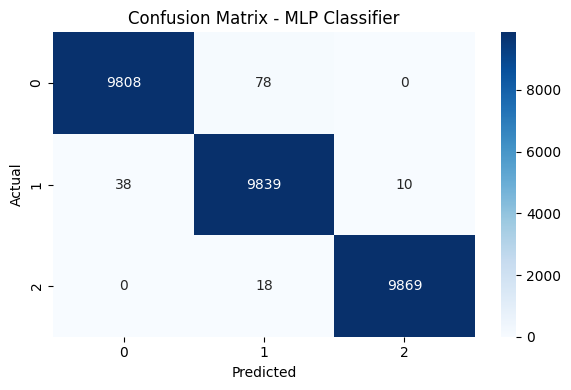

✅ MLPClassifier model trained and evaluated successfully.


In [ ]:
from sklearn.neural_network import MLPClassifier

# Train the MLP Classifier
mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50),  # Two hidden layers with 100 and 50 neurons
                         max_iter=300,                    # Maximum number of iterations
                         activation='relu',               # ReLU activation function
                         solver='adam',                   # Adam optimizer
                         random_state=42)                 # For reproducibility
mlp_model.fit(X_train_transformed, y_train)

# Predict
y_pred = mlp_model.predict(X_test_transformed)  # No .toarray() needed

# Evaluation
print("Multi-layer Perceptron Classifier")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                          index=sorted(set(y_test)),
                          columns=sorted(set(y_test)))

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - MLP Classifier")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ MLPClassifier model trained and evaluated successfully.")

GPU Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8908 - loss: 0.9903 - val_accuracy: 0.9960 - val_loss: 0.0841 - learning_rate: 5.0000e-04
Epoch 2/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9955 - loss: 0.0712 - val_accuracy: 0.9961 - val_loss: 0.0381 - learning_rate: 5.0000e-04
Epoch 3/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9954 - loss: 0.0448 - val_accuracy: 0.9960 - val_loss: 0.0346 - learning_rate: 5.0000e-04
Epoch 4/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9956 - loss: 0.0406 - val_accuracy: 0.9962 - val_loss: 0.0345 - learning_rate: 5.0000e-04
Epoch 5/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9956 - loss: 0.0395 - val_accuracy: 0.9962 - val_loss: 0.0358 - learning_rate: 5.0000e-04
Epoch 6/50
737/742 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9959 - loss: 0.0386
Epoch 6: ReduceLROnPlateau reducing learning rate to 5.0000002374872565e-05.
742/742 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9

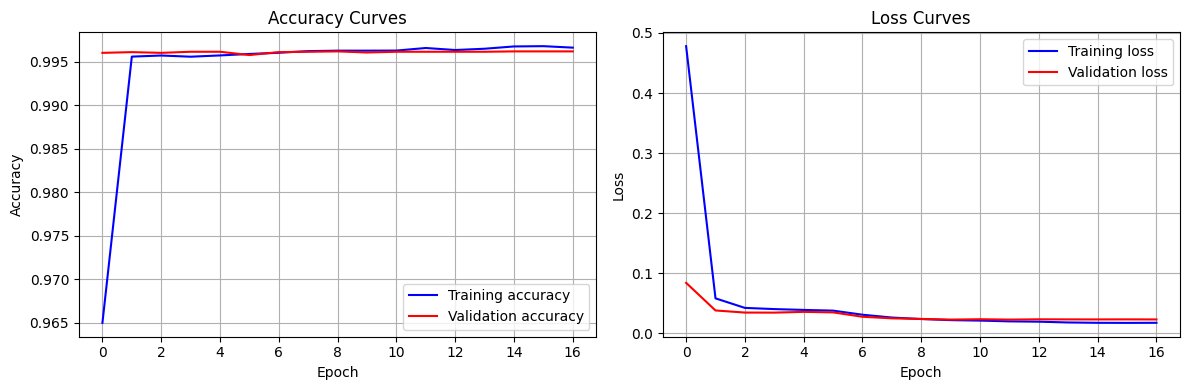

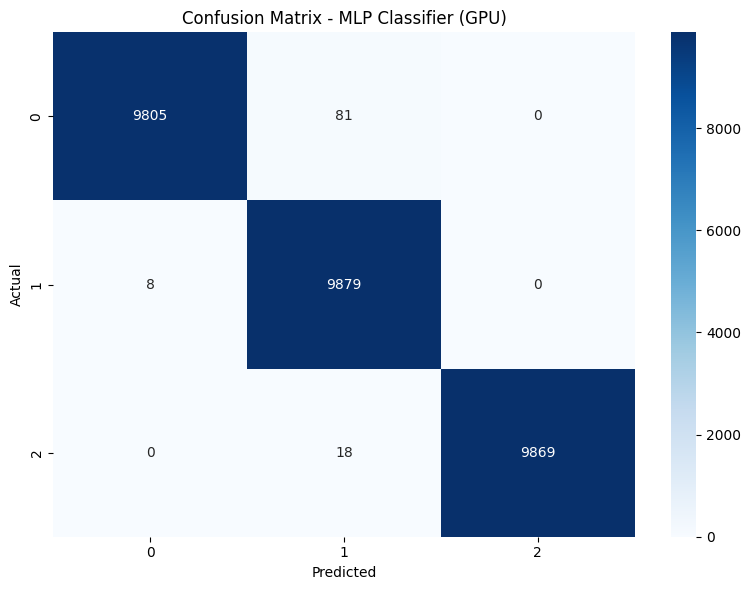

In [ ]:
import tensorflow as tf
import numpy as np

# Verify GPU is available
print("GPU Available: ", tf.config.list_physical_devices('GPU'))

# Convert data to TensorFlow format
X_train = X_train_transformed.toarray() if hasattr(X_train_transformed, 'toarray') else X_train_transformed
X_test = X_test_transformed.toarray() if hasattr(X_test_transformed, 'toarray') else X_test_transformed

# Convert labels to one-hot encoding
y_train_encoded = tf.keras.utils.to_categorical(y_train)
y_test_encoded = tf.keras.utils.to_categorical(y_test)

# Enhanced callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,                  # Reduced patience
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,                 # More aggressive LR reduction
    patience=3,                 # Reduced patience
    min_lr=1e-6,
    verbose=1
)

# Improved model architecture
mlp_gpu_model = tf.keras.Sequential([
    # Input layer
    tf.keras.layers.Dense(64, kernel_regularizer=tf.keras.regularizers.l2(0.01),
                         input_shape=(X_train.shape[1],)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.4),

    # Hidden layer
    tf.keras.layers.Dense(32, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.4),

    # Output layer
    tf.keras.layers.Dense(y_train_encoded.shape[1], activation='softmax')
])

# Compile with improved settings
mlp_gpu_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),  # Lower initial learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train with improvements
history = mlp_gpu_model.fit(
    X_train, y_train_encoded,
    epochs=50,                  # Reduced max epochs
    batch_size=128,            # Increased batch size
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate and predict
y_pred_proba = mlp_gpu_model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# Print metrics
print("\nMulti-layer Perceptron Classifier (GPU)")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Plot improved learning curves
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color='red')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.legend(loc='lower right')
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

conf_matrix = confusion_matrix(y_test, y_pred)

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - MLP Classifier (GPU)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [ ]:
import os
import joblib
from google.colab import drive
from tensorflow.keras.models import load_model

# Mount Google Drive (already done)
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/models'
os.makedirs(save_dir, exist_ok=True)

# ✅ Save Keras model in .keras format
mlp_gpu_model.save(f'{save_dir}/mlp_priority_model.keras')

# ✅ Save scikit-learn preprocessor with joblib
joblib.dump(preprocessor, f'{save_dir}/mlp_priority_preprocessor.joblib')

print("✅ Model and preprocessor saved:")
print(f"📁 MLP Model: {save_dir}/mlp_priority_model.keras")
print(f"📁 Preprocessor: {save_dir}/mlp_priority_preprocessor.joblib")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model and preprocessor saved:
📁 MLP Model: /content/drive/MyDrive/models/mlp_priority_model.keras
📁 Preprocessor: /content/drive/MyDrive/models/mlp_priority_preprocessor.joblib


In [ ]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model

# ✅ Correct paths for Keras and preprocessor
model_path = '/content/drive/MyDrive/models/mlp_priority_model.keras'
preprocessor_path = '/content/drive/MyDrive/models/mlp_priority_preprocessor.joblib'

# ✅ Load models properly
mlp_model = load_model(model_path)
preprocessor = joblib.load(preprocessor_path)

print("✅ Loaded mlp_priority_model (Keras) and mlp_priority_preprocessor")

# ✅ Sample email
sample_email = pd.DataFrame([{
    'urgency_flag': 0,
    'risk_flag': 0,
    'urgency_and_risk': 0,
    'num_action_verbs': 0,
    'num_uppercase_words_subject': 0,
    'subject_len': 1,
    'has_question': 0,
    'Combined_Text': "552071 Can you check this deal with Pacific Gas and Electric We dont have transmission with them Thanks No hurry Ill be out the rest of the day"
}])

# ✅ Preprocess
X_sample_transformed = preprocessor.transform(sample_email)
if hasattr(X_sample_transformed, 'toarray'):
    X_sample_transformed = X_sample_transformed.toarray()

# ✅ Predict and decode class
prediction = mlp_model.predict(X_sample_transformed)
priority = np.argmax(prediction[0])

# ✅ Class label mapping
priority_map = {0: "Low", 1: "Medium", 2: "High"}
print("Email:", '\n\n'.join(sample_email['Combined_Text']))
print("📩 Predicted Email Priority:", priority_map.get(priority, priority))

✅ Loaded mlp_priority_model (Keras) and mlp_priority_preprocessor
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step
Email: 552071 Can you check this deal with Pacific Gas and Electric We dont have transmission with them Thanks No hurry Ill be out the rest of the day
📩 Predicted Email Priority: Medium


# Hybrid Model

SVM, RF, MLP

927/927 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step
Hybrid Model Results:
✅ Accuracy: 0.8297370195549562
📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.49      0.66      9886
           1       0.66      1.00      0.80      9887
           2       1.00      1.00      1.00      9887

    accuracy                           0.83     29660
   macro avg       0.89      0.83      0.82     29660
weighted avg       0.89      0.83      0.82     29660



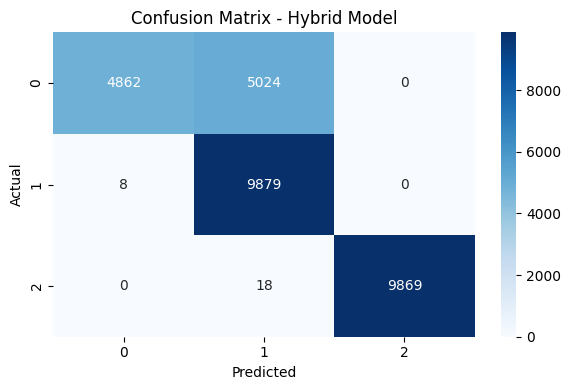

✅ Hybrid model trained and evaluated successfully.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load models
svm_model = joblib.load(svm_model_path)
rf_model = joblib.load(rf_model_path)
mlp_model = joblib.load(mlp_model_path)

def ensemble_predict(X, models, weights=None):
    """
    Make predictions using ensemble of models
    """
    if weights is None:
        weights = [1/len(models)] * len(models)

    all_predictions = []

    # Get predictions from each model
    for model in models:
        if isinstance(model, type(mlp_model)):  # If it's the Keras model
            pred = model.predict(X)
        else:  # For scikit-learn models
            pred = model.predict_proba(X)
        all_predictions.append(pred)

    # Weight and combine predictions
    weighted_predictions = np.average(all_predictions, weights=weights, axis=0)

    # Get final class predictions
    return np.argmax(weighted_predictions, axis=1)

# List of models
hybrid_model = [svm_model, rf_model, mlp_model]

# Set weights based on model performance
weights = [0.40, 0.30, 0.30]

# Make predictions on test set
y_pred = ensemble_predict(X_test_transformed, hybrid_model, weights)

# Evaluate ensemble model
print("Hybrid Model Results:")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                          index=sorted(set(y_test)),
                          columns=sorted(set(y_test)))

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Hybrid Model")  # Changed title to reflect ensemble model
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Hybrid model trained and evaluated successfully.")

927/927 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step
Hybrid Model Results:
✅ Accuracy: 0.8297370195549562
📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.49      0.66      9886
           1       0.66      1.00      0.80      9887
           2       1.00      1.00      1.00      9887

    accuracy                           0.83     29660
   macro avg       0.89      0.83      0.82     29660
weighted avg       0.89      0.83      0.82     29660



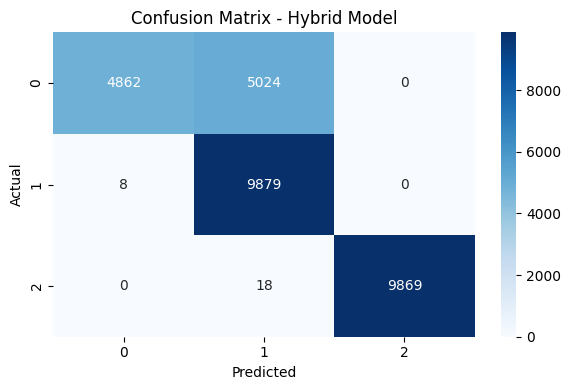

✅ Hybrid model trained and evaluated successfully.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

drive.mount('/content/drive')
svm_model_path = '/content/drive/MyDrive/models/svm_priority_model.joblib'
rf_model_path = '/content/drive/MyDrive/models/rf_priority_model.joblib'
mlp_model_path = '/content/drive/MyDrive/models/mlp_priority_model.joblib'

svm_model = joblib.load(svm_model_path)
rf_model = joblib.load(rf_model_path)
mlp_model = joblib.load(mlp_model_path)

def ensemble_predict(X, models, weights=None):
    """
    Make predictions using ensemble of models
    """
    if weights is None:
        weights = [1/len(models)] * len(models)

    all_predictions = []

    # Get predictions from each model
    for model in models:
        if isinstance(model, type(mlp_model)):  # If it's the Keras model
            pred = model.predict(X)
        else:  # For scikit-learn models
            pred = model.predict_proba(X)
        all_predictions.append(pred)

    # Weight and combine predictions
    weighted_predictions = np.average(all_predictions, weights=weights, axis=0)

    # Get final class predictions
    return np.argmax(weighted_predictions, axis=1)

# List of models
hybrid_model_2 = [svm_model, rf_model, mlp_model]

# Set weights based on model performance
weights = [0.40, 0.30, 0.30]

# Make predictions on test set
y_pred = ensemble_predict(X_test_transformed, hybrid_model_2, weights)

# Evaluate ensemble model
print("Hybrid Model Results:")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                          index=sorted(set(y_test)),
                          columns=sorted(set(y_test)))

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Hybrid Model")  # Changed title to reflect ensemble model
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Hybrid model trained and evaluated successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Hybrid Model Results:
✅ Accuracy: 0.7029669588671612
📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.31      0.48      9886
           1       0.53      1.00      0.69      9887
           2       1.00      0.80      0.89      9887

    accuracy                           0.70     29660
   macro avg       0.84      0.70      0.69     29660
weighted avg       0.84      0.70      0.69     29660



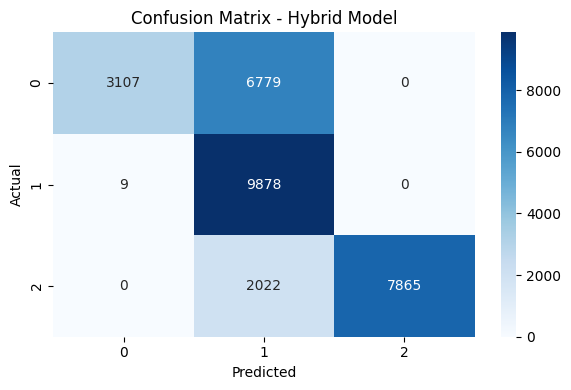

✅ Hybrid model trained and evaluated successfully.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

drive.mount('/content/drive')
svm_model_path = '/content/drive/MyDrive/models/svm_priority_model.joblib'
rf_model_path = '/content/drive/MyDrive/models/rf_priority_model.joblib'
mlp_model_path = '/content/drive/MyDrive/models/mlp_priority_model.joblib'

svm_model = joblib.load(svm_model_path)
rf_model = joblib.load(rf_model_path)
mlp_model = joblib.load(mlp_model_path)

def ensemble_predict(X, models, weights=None):
    """
    Make predictions using ensemble of models
    """
    if weights is None:
        weights = [1/len(models)] * len(models)

    all_predictions = []

    # Get predictions from each model
    for model in models:
        if isinstance(model, type(mlp_model)):  # If it's the Keras model
            pred = model.predict(X)
        else:  # For scikit-learn models
            pred = model.predict_proba(X)
        all_predictions.append(pred)

    # Weight and combine predictions
    weighted_predictions = np.average(all_predictions, weights=weights, axis=0)

    # Get final class predictions
    return np.argmax(weighted_predictions, axis=1)

# List of models
svm_rf_hybrid_models = [svm_model, rf_model]

# Set weights based on model performance
weights = [0.5, 0.5]

# Make predictions on test set
y_pred = ensemble_predict(X_test_transformed, svm_rf_hybrid_models, weights)

# Evaluate ensemble model
print("Hybrid Model Results:")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                          index=sorted(set(y_test)),
                          columns=sorted(set(y_test)))

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Hybrid Model")  # Changed title to reflect ensemble model
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Hybrid model trained and evaluated successfully.")

Fitting 5 folds for each of 66 candidates, totalling 330 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'weights': (np.float64(0.0), np.float64(0.2), np.float64(0.8))}
Best cross-validation score: 0.9966957737487112
927/927 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step

Final Model Results:
✅ Accuracy: 0.9964261631827377
📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      9886
           1       0.99      1.00      0.99      9887
           2       1.00      1.00      1.00      9887

    accuracy                           1.00     29660
   macro avg       1.00      1.00      1.00     29660
weighted avg       1.00      1.00      1.00     29660



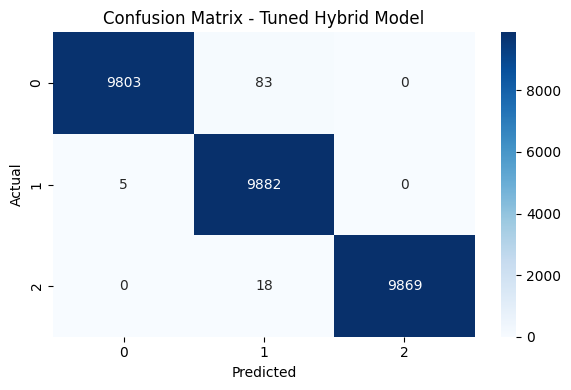

In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV, cross_val_score
from itertools import product
from sklearn.base import BaseEstimator, ClassifierMixin

class EnsembleClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, weights=None):
        self.weights = weights
        self.models = [svm_model, rf_model, mlp_model]

    def fit(self, X, y):
        if self.weights is None:
            self.weights = [1/len(self.models)] * len(self.models)
        return self

    def predict(self, X):
        all_predictions = []

        for model in self.models:
            if isinstance(model, type(mlp_model)):
                pred = model.predict(X)
            else:
                pred = model.predict_proba(X)
            all_predictions.append(pred)

        weighted_predictions = np.average(all_predictions, weights=self.weights, axis=0)
        return np.argmax(weighted_predictions, axis=1)

# Generate weight combinations
def generate_weight_combinations(n_models, step=0.1):
    weights = []
    for w in product(np.arange(0, 1.01, step), repeat=n_models):
        if abs(sum(w) - 1.0) < 1e-10:
            weights.append(w)
    return weights

# Generate weight combinations
weight_combinations = generate_weight_combinations(3, step=0.1)

# Create parameter grid
param_grid = {
    'weights': weight_combinations
}

# Create ensemble
ensemble = EnsembleClassifier()

# Create and fit GridSearchCV
grid_search = GridSearchCV(
    estimator=ensemble,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search.fit(X_train_transformed, y_train)

# Print best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Use best weights for final model
best_weights = grid_search.best_params_['weights']
final_ensemble = EnsembleClassifier(weights=best_weights)

# Make predictions with best model
y_pred = final_ensemble.predict(X_test_transformed)

# Evaluate final model
print("\nFinal Model Results:")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Tuned Hybrid Model")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [ ]:
# Store the best weights and results
best_ensemble_results = {
    'best_weights': grid_search.best_params_['weights'],
    'best_cv_score': grid_search.best_score_,
    'final_accuracy': accuracy_score(y_test, y_pred),
    'classification_report': classification_report(y_test, y_pred),
    'confusion_matrix': conf_matrix.tolist()
}

# Save the results using joblib with better names
joblib.dump(best_ensemble_results, '/content/drive/MyDrive/models/best_ensemble_model_results.joblib')

# Save the final tuned ensemble model
best_ensemble_config = {
    'weights': best_weights,
    'models': ['svm', 'rf', 'mlp']  # Store model names for reference
}
joblib.dump(best_ensemble_config, '/content/drive/MyDrive/models/best_ensemble_model_config.joblib')

print("✅ Best ensemble model results and configuration saved successfully.")

# To load and use the ensemble later:
"""
# Load the configuration and results
best_ensemble_config = joblib.load('/content/drive/MyDrive/models/best_ensemble_model_config.joblib')
best_ensemble_results = joblib.load('/content/drive/MyDrive/models/best_ensemble_model_results.joblib')

# Create new ensemble with best weights
best_ensemble = EnsembleClassifier(weights=best_ensemble_config['weights'])

# Make predictions
predictions = best_ensemble.predict(new_data)
"""

# Print summary of saved information
print("\nBest Ensemble Model Information:")
print("Best Weights:", best_ensemble_results['best_weights'])
print("Best CV Score:", best_ensemble_results['best_cv_score'])
print("Final Test Accuracy:", best_ensemble_results['final_accuracy'])
print("\nClassification Report:")
print(best_ensemble_results['classification_report'])

In [ ]:
from google.colab import drive
import joblib
import os
from google.colab import files  # for downloading

# STEP 1: Mount Google Drive
drive.mount('/content/drive')

# STEP 2: Set save directory in Drive
save_dir = '/content/drive/MyDrive/category models'
os.makedirs(save_dir, exist_ok=True)

# STEP 3: Define file paths
model_path = os.path.join(save_dir, 'final_ensemble_model.pkl')
vectorizer_path = os.path.join(save_dir, 'tfidf_vectorizer.pkl')

# STEP 4: Save model, vectorizer, and scaler to Drive
joblib.dump(final_ensemble, model_path)
joblib.dump(tfidf, vectorizer_path)

print("✅ Files saved to Google Drive.")

# STEP 5: Also download to your local machine
# Temporarily copy to /content before downloading
local_model_path = '/content/final_ensemble_model.pkl'
local_vectorizer_path = '/content/tfidf_vectorizer.pkl'

# Copy from Drive to local Colab space
joblib.dump(final_ensemble, local_model_path)
joblib.dump(tfidf, local_vectorizer_path)

# Download from Colab to your computer
files.download(local_model_path)
files.download(local_vectorizer_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Files saved to Google Drive.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from scipy.stats import mode
from sklearn.metrics import accuracy_score

# Stack predictions from selected models (SVM, RF, LR as example)
all_preds = np.array([
    svm_model.predict(X_test_transformed),
    rf_model.predict(X_test_transformed),
    lr_model.predict(X_test_transformed)
])

# Majority vote
ensemble_pred = mode(all_preds, axis=0, keepdims=False).mode

# Evaluate ensemble
final_accuracy = accuracy_score(y_test, ensemble_pred)

# Save results
best_ensemble_results = {
    'predictions': ensemble_pred,
    'final_accuracy': final_accuracy
}

joblib.dump(best_ensemble_results, '/content/drive/MyDrive/models/best_ensemble_model_results.joblib')
print("✅ Ensemble results saved successfully.")

✅ Ensemble results saved successfully.


Hybrid Model Results:
✅ Accuracy: 0.8704315576534053
📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.61      0.76      9886
           1       0.72      1.00      0.84      9887
           2       1.00      1.00      1.00      9887

    accuracy                           0.87     29660
   macro avg       0.91      0.87      0.87     29660
weighted avg       0.91      0.87      0.87     29660



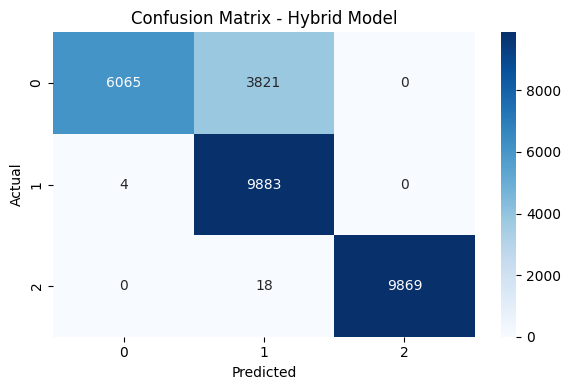

✅ Hybrid model trained and evaluated successfully.


In [ ]:
# Evaluate ensemble model
print("Hybrid Model Results:")
print("✅ Accuracy:", accuracy_score(y_test, ensemble_pred))
print("📊 Classification Report:")
print(classification_report(y_test, ensemble_pred))

# Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, ensemble_pred),
                          index=sorted(set(y_test)),
                          columns=sorted(set(y_test)))

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Hybrid Model")  # Changed title to reflect ensemble model
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Hybrid model trained and evaluated successfully.")

# Model Comparison and Selection

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load all saved models
svm_model = joblib.load('/content/drive/MyDrive/models/svm_priority_model.joblib')
rf_model = joblib.load('/content/drive/MyDrive/models/rf_priority_model.joblib')
mlp_model = joblib.load('/content/drive/MyDrive/models/mlp_priority_model.joblib')
nb_model = joblib.load('/content/drive/MyDrive/models/nb_priority_model.joblib')
lr_model = joblib.load('/content/drive/MyDrive/models/lr_priority_model.joblib')
xgb_model = joblib.load('/content/drive/MyDrive/models/xgb_priority_model.joblib')

# Load best ensemble config and results
best_ensemble_results = joblib.load('/content/drive/MyDrive/models/best_ensemble_model_results.joblib')
best_ensemble_config = joblib.load('/content/drive/MyDrive/models/best_ensemble_model_config.joblib')

# Prediction handler
def get_predictions(model, X):
    if isinstance(model, type(mlp_model)):  # Keras
        pred_proba = model.predict(X)
        return np.argmax(pred_proba, axis=1)
    elif isinstance(model, GaussianNB):
        return model.predict(X.toarray())  # GaussianNB needs dense
    else:
        return model.predict(X)

# === Rebuild the Hybrid (Soft Voting) Prediction ===
model_name_map = {
    'svm': svm_model,
    'rf': rf_model,
    'mlp': mlp_model
}
hybrid_models = [model_name_map[name] for name in best_ensemble_config['models']]
hybrid_weights = best_ensemble_config['weights']

def ensemble_predict(models, weights, X):
    all_preds = []
    for model in models:
        if isinstance(model, type(mlp_model)):
            preds = model.predict(X)
        else:
            preds = model.predict_proba(X)
        all_preds.append(preds)
    weighted_preds = np.average(all_preds, axis=0, weights=weights)
    return np.argmax(weighted_preds, axis=1)

hybrid_pred = ensemble_predict(hybrid_models, hybrid_weights, X_test_transformed)

# === Store all model predictions ===
model_results = {
    'SVM': {
        'model': svm_model,
        'predictions': svm_model.predict(X_test_transformed)
    },
    'Random Forest': {
        'model': rf_model,
        'predictions': rf_model.predict(X_test_transformed)
    },
    'MLP': {
        'model': mlp_model,
        'predictions': get_predictions(mlp_model, X_test_transformed)
    },
    'Naive Bayes': {
        'model': nb_model,
        'predictions': get_predictions(nb_model, X_test_transformed)
    },
    'Logistic Regression': {
        'model': lr_model,
        'predictions': lr_model.predict(X_test_transformed)
    },
    'XGBoost': {
        'model': xgb_model,
        'predictions': xgb_model.predict(X_test_transformed)
    },
    'Hybrid Model': {
        'model': 'Ensemble',
        'predictions': hybrid_pred,
        'accuracy': accuracy_score(y_test, hybrid_pred)
    }
}

# Calculate accuracy for all except hybrid (already computed)
for model_name in model_results:
    if model_name != 'Hybrid Model':
        model_results[model_name]['accuracy'] = accuracy_score(
            y_test, model_results[model_name]['predictions']
        )

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Accuracy': [results['accuracy'] for results in model_results.values()]
}).sort_values('Accuracy', ascending=False)

# Print table
print("Model Comparison:")
print(comparison_df)

# Plot accuracy bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='Model', y='Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print detailed classification reports
print("\nDetailed Classification Reports:")
for model_name, results in model_results.items():
    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_test, results['predictions']))

# Plot confusion matrices for top 4 models
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for (model_name, results), ax in zip(list(model_results.items())[:4], axes.ravel()):
    conf_matrix = confusion_matrix(y_test, results['predictions'])
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

# Save full results
comparison_results = {
    'comparison_table': comparison_df.to_dict(),
    'detailed_results': {
        model_name: {
            'accuracy': results['accuracy'],
            'classification_report': classification_report(y_test, results['predictions']),
            'confusion_matrix': confusion_matrix(y_test, results['predictions']).tolist()
        }
        for model_name, results in model_results.items()
    },
    'best_ensemble_config': best_ensemble_config
}

joblib.dump(comparison_results, '/content/drive/MyDrive/models/complete_model_comparison_results.joblib')

# Final summary
best_model = comparison_df.iloc[0]['Model']
print(f"\n🏆 Best Performing Model: {best_model}")
print(f"✅ Best Accuracy: {comparison_df.iloc[0]['Accuracy']:.4f}")

# Additional metrics
print("\n📊 Detailed Metrics Comparison:")
metrics_df = pd.DataFrame(columns=['Model', 'Precision', 'Recall', 'F1-Score'])

for model_name, results in model_results.items():
    report = classification_report(y_test, results['predictions'], output_dict=True)
    metrics_df = pd.concat([metrics_df, pd.DataFrame([{
        'Model': model_name,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score']
    }])], ignore_index=True)

print(metrics_df.round(4))

927/927 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step
927/927 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:58:16] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


ValueError: Found input variables with inconsistent numbers of samples: [21104, 29660]

Original data shape: (148296, 19)

Removing duplicates...
Data shape after removing duplicates: (35756, 8)

Applying SMOTE to balance classes...

Final dataset shapes:
X_train shape: (84412, 1007)
X_test shape: (21104, 1007)
y_train shape: (84412,)
y_test shape: (21104,)

SVM:
Accuracy: 0.3174

Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.05      0.08      7034
           1       0.32      0.88      0.46      7035
           2       0.32      0.03      0.05      7035

    accuracy                           0.32     21104
   macro avg       0.33      0.32      0.20     21104
weighted avg       0.33      0.32      0.20     21104


Random Forest:
Accuracy: 0.9964

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      7034
           1       0.99      0.99      0.99      7035
           2       1.00      1.00      1.00      7035

    accuracy             

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/xgboost/c


XGBoost:
Accuracy: 0.3313

Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.00      0.01      7034
           1       0.33      0.99      0.50      7035
           2       0.00      0.00      0.00      7035

    accuracy                           0.33     21104
   macro avg       0.19      0.33      0.17     21104
weighted avg       0.19      0.33      0.17     21104


🏆 Model Comparison:
                 Model  Accuracy
1        Random Forest  0.996399
3          Naive Bayes  0.333302
5              XGBoost  0.331264
2                  MLP  0.329937
4  Logistic Regression  0.328516
0                  SVM  0.317428


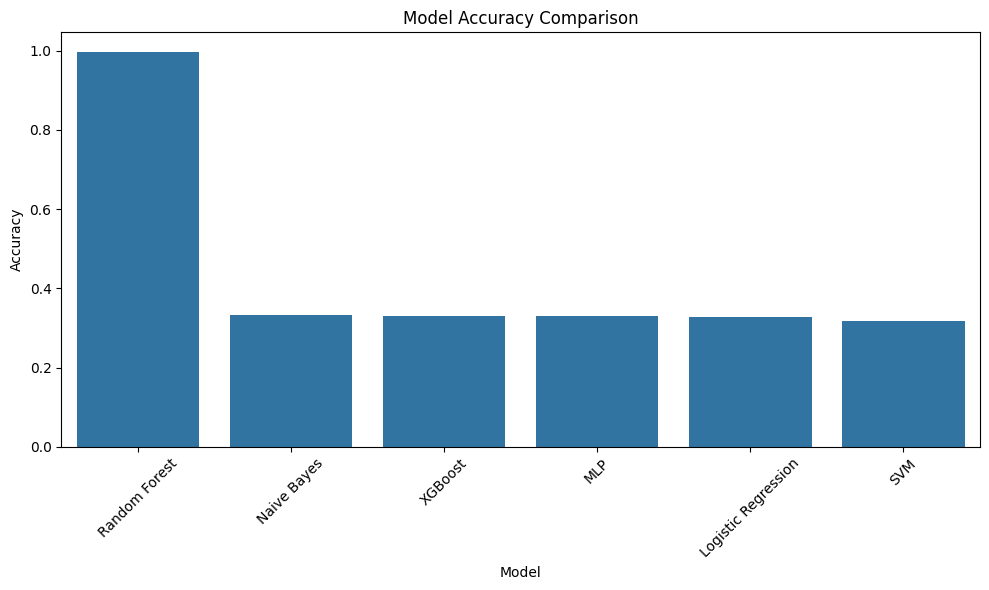

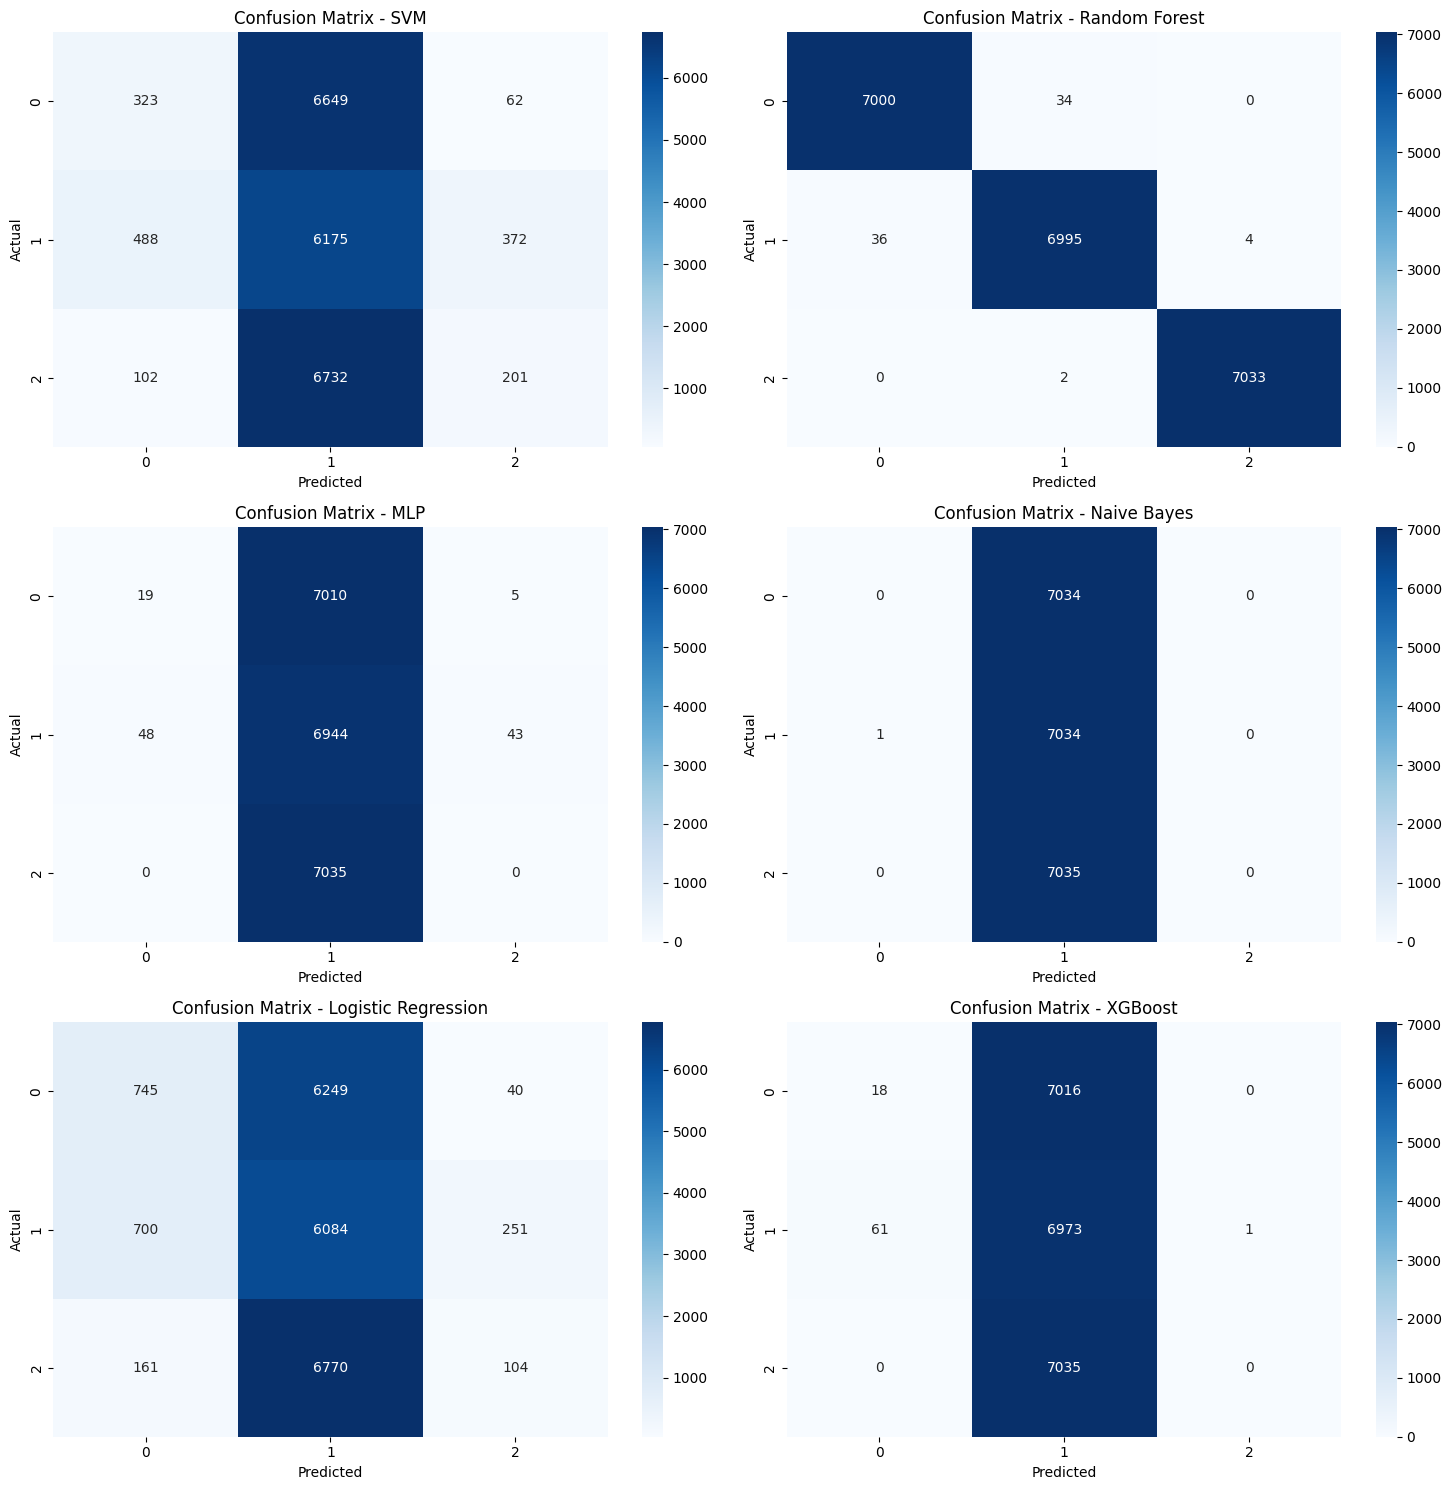


📊 Detailed Metrics Comparison:
                 Model  Precision  Recall  F1-Score
1        Random Forest     0.9964  0.9964    0.9964
4  Logistic Regression     0.3485  0.3285    0.2220
0                  SVM     0.3287  0.3174    0.1994
5              XGBoost     0.1865  0.3313    0.1674
2                  MLP     0.2048  0.3299    0.1670
3          Naive Bayes     0.1111  0.3333    0.1667

✅ Results saved successfully!


<ipython-input-37-941144e53e42>:166: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, pd.DataFrame([{
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# First, let's recreate the correct test set
print("Original data shape:", email_data.shape)

# 1. Define features
structured_features = [
    'urgency_flag', 'risk_flag',
    'urgency_and_risk', 'num_action_verbs', 'num_uppercase_words_subject',
    'subject_len', 'has_question'
]
text_feature = 'Combined_Text'

# 2. Create feature matrix and target
X = email_data[structured_features + [text_feature]]
y = email_data['Email_Priority']

# 3. Remove duplicates
print("\nRemoving duplicates...")
X_text = X[text_feature].values
X_structured = X[structured_features].values
combined_features = np.hstack([X_structured, X_text.reshape(-1, 1)])

unique_indices = pd.DataFrame(combined_features).drop_duplicates().index
X_unique = X.iloc[unique_indices]
y_unique = y.iloc[unique_indices]

print("Data shape after removing duplicates:", X_unique.shape)

# 4. Apply SMOTE to balance classes
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

print("\nApplying SMOTE to balance classes...")
# First, create TF-IDF features
tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    lowercase=True
)

# Transform text data
X_text_tfidf = tfidf.fit_transform(X_unique[text_feature])

# Combine with structured features
X_structured_scaled = StandardScaler().fit_transform(X_unique[structured_features])
X_combined = np.hstack([X_structured_scaled, X_text_tfidf.toarray()])

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined, y_unique)

# 5. Split the balanced data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    stratify=y_resampled,
    test_size=0.2,
    random_state=42
)

print("\nFinal dataset shapes:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Load all saved models
svm_model = joblib.load('/content/drive/MyDrive/models/svm_priority_model.joblib')
rf_model = joblib.load('/content/drive/MyDrive/models/rf_priority_model_balanced.joblib')
mlp_model = joblib.load('/content/drive/MyDrive/models/mlp_priority_model.joblib')
nb_model = joblib.load('/content/drive/MyDrive/models/nb_priority_model.joblib')
lr_model = joblib.load('/content/drive/MyDrive/models/lr_priority_model.joblib')
xgb_model = joblib.load('/content/drive/MyDrive/models/xgb_priority_model.joblib')

# Prediction handler
def get_predictions(model, X):
    if isinstance(model, type(mlp_model)):  # Keras
        pred_proba = model.predict(X)
        return np.argmax(pred_proba, axis=1)
    elif isinstance(model, GaussianNB):
        return model.predict(X.toarray() if hasattr(X, 'toarray') else X)
    else:
        return model.predict(X)

# Store all model predictions
model_results = {}

# Add individual model predictions
for model_name, model in [
    ('SVM', svm_model),
    ('Random Forest', rf_model),
    ('MLP', mlp_model),
    ('Naive Bayes', nb_model),
    ('Logistic Regression', lr_model),
    ('XGBoost', xgb_model)
]:
    try:
        predictions = get_predictions(model, X_test)
        accuracy = accuracy_score(y_test, predictions)
        model_results[model_name] = {
            'model': model,
            'predictions': predictions,
            'accuracy': accuracy
        }
        print(f"\n{model_name}:")
        print(f"Accuracy: {accuracy:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, predictions))
    except Exception as e:
        print(f"Error processing {model_name}:", str(e))

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Accuracy': [results['accuracy'] for results in model_results.values()]
}).sort_values('Accuracy', ascending=False)

# Print table
print("\n🏆 Model Comparison:")
print(comparison_df)

# Plot accuracy bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='Model', y='Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot confusion matrices for all models
n_models = len(model_results)
n_cols = 2
n_rows = (n_models + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.ravel()

for idx, (model_name, results) in enumerate(model_results.items()):
    conf_matrix = confusion_matrix(y_test, results['predictions'])
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - {model_name}')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

# Remove empty subplots if any
for idx in range(len(model_results), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# Additional metrics
print("\n📊 Detailed Metrics Comparison:")
metrics_df = pd.DataFrame(columns=['Model', 'Precision', 'Recall', 'F1-Score'])

for model_name, results in model_results.items():
    report = classification_report(y_test, results['predictions'], output_dict=True)
    metrics_df = pd.concat([metrics_df, pd.DataFrame([{
        'Model': model_name,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score']
    }])], ignore_index=True)

print(metrics_df.sort_values('F1-Score', ascending=False).round(4))

# Save results
comparison_results = {
    'comparison_table': comparison_df.to_dict(),
    'detailed_metrics': metrics_df.to_dict(),
    'detailed_results': {
        model_name: {
            'accuracy': results['accuracy'],
            'classification_report': classification_report(y_test, results['predictions']),
            'confusion_matrix': confusion_matrix(y_test, results['predictions']).tolist()
        }
        for model_name, results in model_results.items()
    }
}

joblib.dump(comparison_results, '/content/drive/MyDrive/models/complete_model_comparison_results.joblib')
print("\n✅ Results saved successfully!")

In [ ]:
print("Train shape:", X_train_transformed.shape)
print("Test shape:", X_test_transformed.shape)

Train shape: (118636, 1007)
Test shape: (29660, 1007)


In [ ]:
print("y_train distribution:\n", pd.Series(y_train).value_counts())
print("y_test distribution:\n", pd.Series(y_test).value_counts())

y_train distribution:
 Email_Priority
0    28138
2    28137
1    28137
Name: count, dtype: int64
y_test distribution:
 Email_Priority
2    7035
1    7035
0    7034
Name: count, dtype: int64


In [ ]:
y_pred = svm_model.predict(X_test_transformed)

print("Predictions:", y_pred[:10])
print("Actual:", y_test[:10].values)

Predictions: [0 2 2 2 0 0 0 1 0 2]
Actual: [0 0 2 1 0 0 1 0 1 1]


In [ ]:
import numpy as np

y_pred_labels = np.argmax(y_pred, axis=1)

print("Predicted Labels:", y_pred_labels[:10])
print("Actual Labels:   ", y_test[:10].values)

In [ ]:
y_pred = rf_model.predict(X_test_transformed)

print("Predictions:", y_pred[:10])
print("Actual:", y_test[:10].values)

Predictions: [1 1 0 1 1 1 1 1 1 1]
Actual: [0 0 2 1 0 0 1 0 1 1]


In [ ]:
y_pred = xgb_model.predict(X_test_transformed)

print("Predictions:", y_pred[:10])
print("Actual:", y_test[:10].values)

Predictions: [1 2 2 2 1 1 1 1 1 2]
Actual: [0 0 2 1 0 0 1 0 1 1]


In [ ]:
y_pred = nb_model.predict(X_test_transformed.toarray())

print("Predictions:", y_pred[:10])
print("Actual:", y_test[:10].values)

Predictions: [0 1 1 1 1 1 1 1 1 1]
Actual: [0 0 2 1 0 0 1 0 1 1]


In [ ]:
y_pred = best_ensemble_results.predict(X_test_transformed)

print("Predictions:", y_pred[:10])
print("Actual:", y_test[:10].values)

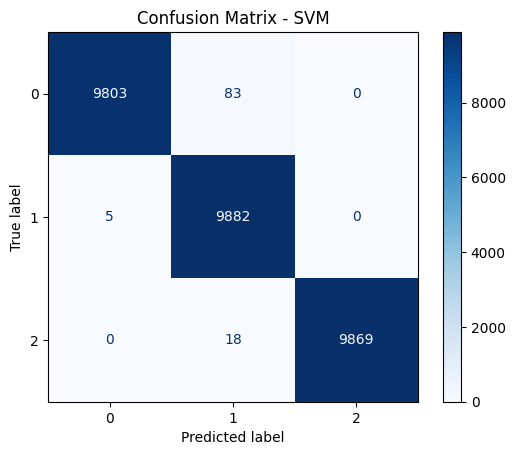

927/927 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step


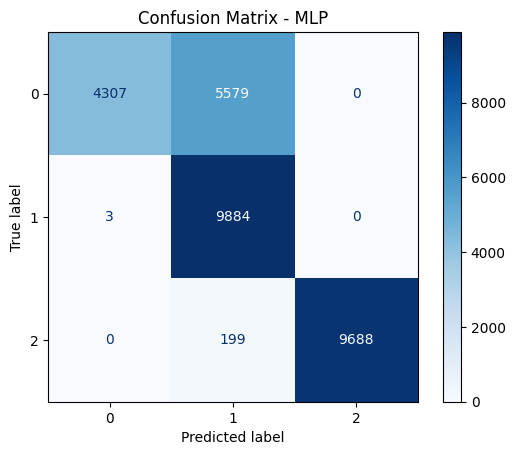

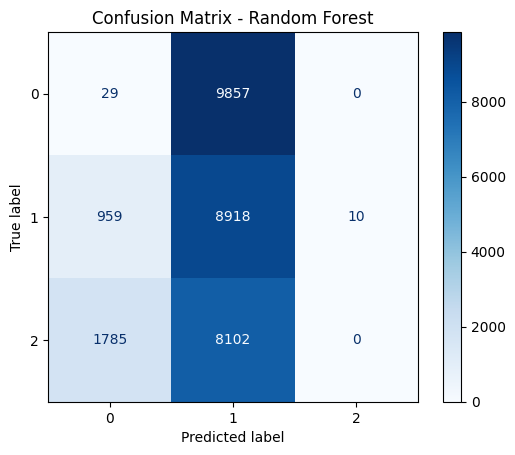

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

for model_name, model in zip(
    ['SVM', 'MLP', 'Random Forest'],
    [svm_model, mlp_model, rf_model]
):
    y_pred = model.predict(X_test_transformed.toarray() if model_name == 'Naive Bayes' else X_test_transformed)
    if model_name == 'MLP':
        y_pred = np.argmax(y_pred, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

In [ ]:
# During training
train_pred = rf_model.predict(X_train_transformed)
test_pred = rf_model.predict(X_test_transformed)
print("Training accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, test_pred))

Training accuracy: 0.582243163963721
Test accuracy: 0.5822993931220499
